# Service 4 — External validation on open data

**EnerTEF · TEF-EV · Service 4 — EV-User Charging and Usage Profiles Prediction · D2.2 §2.5.4**

The models in this repository were built and scored on four Irish households. This notebook tests them on **open data
from outside that pilot** and, on the way, checks whether the published headline numbers hold against *stronger
baselines*. It reads `Data/models/`; it writes there only the open sample file of §3.7, and only if you set `PUBLISH_SAMPLE_TO_MODEL_DIR`.

| Part | Question | Data |
|---|---|---|
| **A** | How does the **deployed session-energy model** (`session_energy.joblib`) behave, zero-shot, on a different vehicle and usage? | Renault Zoe data-logger, trips **and** charging — [Zenodo 7033914](https://zenodo.org/records/7033914) (CC-BY-4.0) |
| **B** | Do the **will-charge, energy-volume and dwell heads**, and the quantile-GBR design, hold up on a large residential data set? | 35,377 real sessions, 267 users, 12 sites in Norway — [Zenodo 13896176](https://zenodo.org/records/13896176) (CC-BY-4.0) |
| **C** | Are the **published baselines** strong enough yardsticks? | The Dingle data and `outputs/` of the other two notebooks (skipped if absent) |

### Why two data sets, and what each can and cannot show

The deployed model needs the **distance driven between charging sessions**. Almost no open charging data records it. The
Zoe logger is the only open set found that links driving and charging on the same vehicle, but it is small (about 60
usable sessions) and unlike the pilot (two cars with 22 and 37 kWh packs, mostly short morning top-ups, over half of them on 20–21 kW AC chargers). Part A is therefore a
**smoke test**: it can rule out a large transfer advantage, not measure a small one.

The Norwegian sessions are large but carry no driving data, so the saved model cannot run on them. Part B re-fits the
heads on the features that exist without driving (no `km_*`, no reconstructed state of charge): it tests the
**approach**, not the saved model. Only `Dataset1` of that record is measured; its `Dataset2–4` (battery size, plug-in
state of charge, hourly profiles) are model-predicted and are deliberately not used.

### Data access

Both files are downloaded from Zenodo on first run into `Data/external/` (git-ignored, about 125 MB), verified by MD5, and
cached. Nothing needs registering. The Dingle data is only needed for the pipeline gate and Part C.

### How to run

The shipped model is a pickle written by **scikit-learn 1.5.2**; it does **not load on scikit-learn 1.6 or newer**.
`requirements.txt` pins the reference environment (Python 3.11 · numpy 1.26.4 · pandas 2.2.3 · scikit-learn 1.5.2 ·
joblib 1.4.2, see `Data/models/metrics.json`): create a Python 3.11 (or 3.12) environment, `pip install -r requirements.txt`,
and run top to bottom from the repository root.
First run about 5 minutes (the 2.2 GB logger file is streamed once and cached as a 2 MB minute table).

| § | Section |
|---|---|
| 1 | Setup, model load, downloads |
| 2 | Shared pipeline and the **parity gate** (does this notebook reproduce the published hold-out exactly?) |
| 3 | **Part A** — Zoe: reduction, vehicles, journeys and sessions, completeness filter, zero-shot scores, robustness |
| 4 | **Part B** — Norway: panel, Head A, session energy, volume, dwell, segmentation |
| 5 | **Part C** — baseline-strength check on the original results |
| 6 | Summary and limitations |

## 1 · Setup

In [1]:
import hashlib
import json
import os
import platform
import statistics
import urllib.request
import warnings
from datetime import datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

# joblib cannot count physical cores on recent Windows (no `wmic`) and prints a traceback when
# LightGBM asks for them; a core count below the logical total makes it skip that probe.
if os.name == "nt":
    os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) // 2)))

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, average_precision_score, brier_score_loss, f1_score,
                             mean_absolute_error, roc_auc_score, silhouette_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "legend.frameon": False})

ROOT = Path.cwd()
DATA_DIR = Path(os.environ.get("DINGLE_DATASET_ROOT") or ROOT / "Data")      # Dingle data (optional in this notebook)
MODEL_PATH = ROOT / "Data" / "models" / "session_energy.joblib"
EXT_DIR = ROOT / "Data" / "external"                                          # downloaded open data (git-ignored)
OUT_DIR = ROOT / "outputs"
EXT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)
RESULTS = {}                                                                  # every number quoted in the summary

LIBS = {lib: version(lib) for lib in ("numpy", "pandas", "scikit-learn", "lightgbm", "joblib")}
print(f"python {platform.python_version()} · " + " · ".join(f"{lib} {v}" for lib, v in LIBS.items()))

try:
    BUNDLE = joblib.load(MODEL_PATH)
except Exception as err:      # the pickle only loads on the scikit-learn release that wrote it
    raise RuntimeError(
        f"{MODEL_PATH.name} could not be loaded with scikit-learn {LIBS['scikit-learn']} ({type(err).__name__}: {err}). "
        "It was written with scikit-learn 1.5.2 and does not load on 1.6 or newer. Create a Python 3.11 (or 3.12) environment "
        "and `pip install -r requirements.txt`, which pins the reference versions.") from err
FEATURES, MODELS = BUNDLE["features"], BUNDLE["quantiles"]
print(f"loaded {MODEL_PATH.name}: version {BUNDLE['version']} · {BUNDLE['algorithm']} · features {FEATURES}")

python 3.11.9 · numpy 1.26.4 · pandas 2.2.3 · scikit-learn 1.5.2 · lightgbm 4.5.0 · joblib 1.4.2
loaded session_energy.joblib: version 1.0.0 · sklearn_gbr · features ['recent_trip_km', 'trips_today', 'hours_since_last_charge', 'tariff_ordinal', 'pv_today_kwh', 'hour_of_day', 'is_weekend']


### Downloads

Zenodo's file API serves each file directly. The MD5 values are the ones Zenodo publishes for these records.

In [2]:
ZENODO = {
    "zoe": {"record": 7033914, "file": "Time_series_electric_vehicle.zip", "md5": "f71321e3cc74c6f4e0a2efde689babc9"},
    "norway": {"record": 13896176, "file": "Dataset1_charging_reports.csv", "md5": "8bb7463d760cc846271b1ed9bdf808fd"},
}


def md5_of(path, block=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(block), b""):
            h.update(chunk)
    return h.hexdigest()


def fetch(key):
    spec = ZENODO[key]
    dest = EXT_DIR / spec["file"]
    if dest.exists() and md5_of(dest) == spec["md5"]:
        return dest
    url = f"https://zenodo.org/api/records/{spec['record']}/files/{spec['file']}/content"
    tmp = dest.with_suffix(dest.suffix + ".part")
    print(f"downloading {spec['file']} (Zenodo record {spec['record']}) ...")
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "ev-service4-validation/1.0"})
        with urllib.request.urlopen(req, timeout=120) as resp, open(tmp, "wb") as out:
            while chunk := resp.read(1 << 20):
                out.write(chunk)
    except OSError as err:
        raise RuntimeError(f"download failed ({err}); fetch the file from https://zenodo.org/records/{spec['record']} "
                           f"and place it at {dest}") from err
    if md5_of(tmp) != spec["md5"]:
        tmp.unlink()
        raise RuntimeError(f"MD5 mismatch for {spec['file']}: the download is corrupt, run the cell again")
    tmp.replace(dest)
    return dest


ZOE_ZIP, NORWAY_CSV = fetch("zoe"), fetch("norway")
for p in (ZOE_ZIP, NORWAY_CSV):
    print(f"{p.name:40s} {p.stat().st_size / 1e6:8.1f} MB  md5 verified")

Time_series_electric_vehicle.zip            121.4 MB  md5 verified
Dataset1_charging_reports.csv                 3.1 MB  md5 verified


## 2 · Shared pipeline and the parity gate

The feature rules below are **copied unchanged** from `EV_Session_Energy_Model.ipynb` (§2–4): the same 7 features, the same
leakage-safe context (strictly before the session start), the same baseline (distance × 0.18 kWh/km, +5 % per trip
beyond the first, clamped to 1–80 kWh, ±25 % band) and the same scores. An external data set is turned into the model's
inputs by exactly these rules, with two unobservable inputs left at the notebook's own "unknown" values: the tariff band
(`standard`, ordinal 2) and the PV generated today (0).

**Parity gate.** If the Dingle data is present, the cell below rebuilds its features, runs the *shipped* model on the
held-out 20 % and compares with the published `metrics.json`. If they agree to the third decimal, the copied pipeline and
the environment are faithful and Part A can be trusted.

In [3]:
TARIFF_ORDINAL = {"off_peak": 0, "shoulder": 1, "standard": 2, "peak": 3}
DEFAULT_HOURS_SINCE_LAST_CHARGE = 18.0
QUANTILES = {"q10": 0.1, "q50": 0.5, "q90": 0.9}


# ---- copied from EV_Session_Energy_Model.ipynb §2 (Dingle loading) --------------------------------------------------
def parse_event_ts(value):
    try:
        return datetime.strptime(str(value).strip(), "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
    except ValueError:
        return None


def parse_float(value):
    text = str(value).strip()
    try:
        return float(text) if text else None
    except ValueError:
        return None


def charging_minutes(value):
    parts = str(value).strip().split(":")
    try:
        h, m, s = (int(p) for p in parts)
    except ValueError:
        return None
    return h * 60 + m + s / 60.0


def find_file(subdir, household):
    for pattern in (f"{household}_*.csv", f"{household}*.csv"):
        matches = sorted((DATA_DIR / subdir).glob(pattern))
        if matches:
            return matches[0]
    return None


def load_events(household):
    log = pd.read_csv(find_file("JourneyCharge", household), dtype=str, keep_default_na=False)
    sessions, journeys = [], []
    for row in log.to_dict("records"):
        event = (row.get("event_type") or "").strip().lower()
        start = parse_event_ts(row.get("start_time", ""))
        if start is None:
            continue
        if event == "charging":
            energy = parse_float(row.get("ENERGY", ""))
            if energy is None or energy <= 0:
                continue
            end = parse_event_ts(row.get("end_time", ""))
            if end is None:
                end = start + timedelta(minutes=charging_minutes(row.get("CHARGING_TIME", "")) or 0.0)
            sessions.append({"start": start, "end": end, "energy_kwh": energy})
        elif event == "journey":
            distance = parse_float(row.get("Distance", ""))
            if distance is not None and distance > 0:
                journeys.append({"start": start, "distance_km": distance})
    return sessions, journeys


def load_stream(household):
    df = pd.read_csv(find_file("EnergyStreams", household), dtype=str, keep_default_na=False)
    stream = {}
    for ts, solar, price in zip(df["timestamp"], df["solar_kWh"], df["elec_price"]):
        try:
            slot = datetime.fromisoformat(ts.strip()).astimezone(timezone.utc)
        except ValueError:
            continue
        stream[slot] = (parse_float(solar), parse_float(price))
    return stream


def slot_of(ts):
    return ts.replace(minute=0 if ts.minute < 30 else 30, second=0, microsecond=0)


def tariff_band(price, terciles):
    if price is None or terciles is None:
        return None
    low, high = terciles
    return "off_peak" if price <= low else "peak" if price >= high else "shoulder"


def attach_tariff(sessions, stream):
    prices = sorted(p for _, p in stream.values() if p is not None)
    terciles = tuple(statistics.quantiles(prices, n=3)) if len(prices) >= 3 and prices[0] != prices[-1] else None
    for s in sessions:
        s["tariff_band"] = tariff_band(stream.get(slot_of(s["start"]), (None, None))[1], terciles)


# ---- copied from §3 (features) and §4 (baseline, scores) -----------------------------------------------------------
def pv_today_kwh(stream, until):
    cursor, total = until.replace(hour=0, minute=0, second=0, microsecond=0), 0.0
    while cursor < until:
        solar = stream.get(slot_of(cursor), (None, None))[0]
        if solar:
            total += solar
        cursor += timedelta(minutes=30)
    return round(total, 3)


def build_rows(household, d):
    rows, prev_end = [], None
    for s in sorted(d["sessions"], key=lambda x: x["start"]):
        start = s["start"]
        window_start = prev_end if prev_end is not None else start - timedelta(hours=24)
        rows.append({
            "household": household,
            "start": start,
            "recent_trip_km": round(sum(j["distance_km"] for j in d["journeys"] if window_start <= j["start"] < start), 3),
            "trips_today": sum(1 for j in d["journeys"] if j["start"].date() == start.date() and j["start"] < start),
            "hours_since_last_charge": (max(0.0, (start - prev_end).total_seconds() / 3600.0)
                                        if prev_end is not None else DEFAULT_HOURS_SINCE_LAST_CHARGE),
            "tariff_ordinal": float(TARIFF_ORDINAL.get(s.get("tariff_band") or "standard", 2)),
            "pv_today_kwh": pv_today_kwh(d["stream"], start),
            "hour_of_day": start.hour + start.minute / 60.0,
            "is_weekend": 1.0 if start.weekday() >= 5 else 0.0,
            "energy_kwh": s["energy_kwh"],
        })
        prev_end = s["end"]
    return rows


def baseline(frame):
    energy = frame.recent_trip_km.to_numpy() * 0.18 * (1.0 + 0.05 * np.maximum(0, frame.trips_today.to_numpy() - 1))
    energy = np.clip(energy, 1.0, 80.0)
    return np.maximum(0.0, energy * 0.75 - 1.0), energy, np.minimum(80.0 * 1.2, energy * 1.25 + 1.0)


def scores(actual, lo, mid, hi):
    err = mid - actual
    return {"mae_kwh": round(float(np.mean(np.abs(err))), 3), "rmse_kwh": round(float(np.sqrt(np.mean(err ** 2))), 3),
            "bias_kwh": round(float(np.mean(err)), 3),
            "coverage_q10_q90_pct": round(100 * float(np.mean((lo <= actual) & (actual <= hi))), 1)}


def predict_sorted(models, X):
    return tuple(np.sort(np.vstack([models[q].predict(X) for q in QUANTILES]), axis=0))


# ---- parity gate --------------------------------------------------------------------------------------------------
def dingle_table():
    if not all((DATA_DIR / d).is_dir() for d in ("JourneyCharge", "EnergyStreams")):
        return None
    rows = []
    for hid in ("id01", "id02", "id03", "id04"):
        sessions, journeys = load_events(hid)
        stream = load_stream(hid)
        attach_tariff(sessions, stream)
        rows += build_rows(hid, {"sessions": sessions, "journeys": journeys, "stream": stream})
    table = pd.DataFrame(rows)
    return table.iloc[np.argsort([t.timestamp() for t in table.start])].reset_index(drop=True)


DINGLE = dingle_table()
if DINGLE is None:
    print("Dingle data not found under", DATA_DIR, "- the parity gate and Part C are skipped (Parts A and B do not need it).")
    RESULTS["parity"] = "skipped (Dingle data absent)"
else:
    cut = int(len(DINGLE) * 0.8)
    held = DINGLE.iloc[cut:]
    X_held, y_held = held[FEATURES].to_numpy(float), held.energy_kwh.to_numpy()
    mine = scores(y_held, *predict_sorted(MODELS, X_held))
    mine_base = scores(y_held, *baseline(held))
    published = json.loads((ROOT / "Data" / "models" / "metrics.json").read_text())
    table = pd.DataFrame({"this notebook": mine, "published": published["holdout"],
                          "baseline (this notebook)": mine_base, "baseline (published)": published["baseline_holdout"]})
    display(table)
    ok = all(abs(mine[k] - published["holdout"][k]) < 0.01 for k in mine) and \
        all(abs(mine_base[k] - published["baseline_holdout"][k]) < 0.01 for k in mine_base)
    RESULTS["parity"] = "PASS" if ok else "MISMATCH"
    print("PARITY GATE:", "PASS - identical to the published hold-out" if ok else
          "MISMATCH - the environment or the data differ from the reference run; do not trust Part A")

,this notebook,published,baseline (this notebook),baseline (published)
mae_kwh,10.461,10.461,18.723,18.723
rmse_kwh,14.197,14.197,25.883,25.883
bias_kwh,-1.904,-1.904,-2.590,-2.590
coverage_q10_q90_pct,79.600,79.600,36.100,36.100


PARITY GATE: PASS - identical to the published hold-out


## 3 · Part A — the deployed model on a Renault Zoe data-logger

**Source.** Morea, Alessandrini & Spadaro (Area Science Park, 2022), *Electric car parameters over 29 months*,
[Zenodo 7033914](https://zenodo.org/records/7033914), CC-BY-4.0: an OBD logger on an electric car, with state of charge,
odometer and speed — so **both trips and charging** are recoverable.

**What the file actually contains** (the record's description is more generous than the files):

* The member labelled `2019-01-01_2020-01-19` holds **one day** (19 Jan 2020). Real coverage is
  **20 Jan 2020 → 29 May 2021**, one row per second (`;`-separated, decimal comma, `ND` = no data), 2.2 GB unzipped.
* The zip uses **Deflate64**, which Python's `zipfile` cannot decode; a 20-line reader on top of `inflate64` does (checked byte-for-byte against `unzip`).
* Only about 4 % of the seconds carry data (the car's bus is asleep otherwise) and logging is patchy (none in Oct 2020).
* `Available_Charging_Power` and `Charging_Power` are **not** charging indicators (the first is a constant 2.1 kW even while
  driving). Charging sessions are therefore detected from **state of charge rising while parked**.

In [4]:
import io
import struct
import zipfile

try:
    import inflate64
except ImportError as err:
    raise ImportError("pip install inflate64  (the Zoe archive uses Deflate64, which zipfile cannot read)") from err


class Deflate64Reader(io.RawIOBase):
    # Binary file-like object over one Deflate64 (zip compression method 9) member. The stdlib zipfile reads the central
    # directory of such an archive but cannot decode the data; inflate64 can. Checked byte-for-byte against Info-ZIP `unzip`.
    def __init__(self, zip_path, member, block=1 << 20):
        with zipfile.ZipFile(zip_path) as z:
            info = z.getinfo(member)
        if info.compress_type != 9:
            raise ValueError(f"{member} uses compression method {info.compress_type}, not Deflate64")
        self._f = open(zip_path, "rb")
        self._f.seek(info.header_offset)
        name_len, extra_len = struct.unpack("<HH", self._f.read(30)[26:30])
        self._f.seek(info.header_offset + 30 + name_len + extra_len)
        self._left, self._block = info.compress_size, block
        self._inflater, self._buf, self._done = inflate64.Inflater(), b"", False

    def readable(self):
        return True

    def readinto(self, b):
        while not self._buf and not self._done:
            chunk = self._f.read(min(self._block, self._left)) if self._left > 0 else b""
            self._left -= len(chunk)
            self._buf = self._inflater.inflate(chunk) if chunk else b""
            if not chunk or self._inflater.eof:
                self._done = True
        n = min(len(b), len(self._buf))
        b[:n] = self._buf[:n]
        self._buf = self._buf[n:]
        return n

    def close(self):
        self._f.close()
        super().close()


ZOE_MEMBER = "ZOE_CSV_2020-01-20_2021-05-29.csv"
ZOE_COLS = ["date", "time", "avail_e", "consumption", "rpm", "torque", "odo", "speed", "soc", "throttle", "avail_cp", "charge_p"]
ZOE_SIGNALS = ZOE_COLS[2:]
ZOE_MINUTE = EXT_DIR / "zoe_minute.csv"


def reduce_zoe(zip_path, out_csv):
    # Stream the per-second file once and keep one aggregated row per awake minute (about 1 minute of compute).
    parts, total = [], 0
    with io.BufferedReader(Deflate64Reader(zip_path, ZOE_MEMBER), buffer_size=1 << 20) as f:
        reader = pd.read_csv(f, sep=";", skiprows=2, header=None, names=ZOE_COLS, decimal=",", na_values=["ND"],
                             dtype={**{c: "float64" for c in ZOE_SIGNALS}, "date": "string", "time": "string"},
                             chunksize=2_000_000)
        for chunk in reader:
            total += len(chunk)
            chunk = chunk[chunk[ZOE_SIGNALS].notna().any(axis=1)]
            if chunk.empty:
                continue
            ts = pd.to_datetime(chunk["date"] + " " + chunk["time"], format="%d/%m/%Y %H:%M:%S")
            g = chunk.assign(minute=ts.dt.floor("min")).groupby("minute")
            parts.append(pd.DataFrame({
                "n_sec": g.size(), "odo_first": g["odo"].first(), "odo_last": g["odo"].last(),
                "speed_sum": g["speed"].sum(min_count=1), "speed_cnt": g["speed"].count(), "speed_max": g["speed"].max(),
                "soc_first": g["soc"].first(), "soc_last": g["soc"].last(), "avail_e_last": g["avail_e"].last(),
                "charge_p_sum": g["charge_p"].sum(min_count=1), "charge_p_cnt": g["charge_p"].count(),
                "avail_cp_sum": g["avail_cp"].sum(min_count=1), "avail_cp_cnt": g["avail_cp"].count()}))
    g = pd.concat(parts).sort_index().groupby(level=0)         # a minute can straddle two chunks: merge the halves
    m = pd.DataFrame({
        "n_sec": g["n_sec"].sum(), "odo_first": g["odo_first"].first(), "odo_last": g["odo_last"].last(),
        "speed_sum": g["speed_sum"].sum(min_count=1), "speed_cnt": g["speed_cnt"].sum(), "speed_max": g["speed_max"].max(),
        "soc_first": g["soc_first"].first(), "soc_last": g["soc_last"].last(), "avail_e_last": g["avail_e_last"].last(),
        "charge_p_sum": g["charge_p_sum"].sum(min_count=1), "charge_p_cnt": g["charge_p_cnt"].sum(),
        "avail_cp_sum": g["avail_cp_sum"].sum(min_count=1), "avail_cp_cnt": g["avail_cp_cnt"].sum()})
    m["speed_mean"] = m.speed_sum / m.speed_cnt.replace(0, np.nan)
    m["charge_p"] = m.charge_p_sum / m.charge_p_cnt.replace(0, np.nan)
    m["avail_cp"] = m.avail_cp_sum / m.avail_cp_cnt.replace(0, np.nan)
    m = m.drop(columns=["speed_sum", "speed_cnt", "charge_p_sum", "charge_p_cnt", "avail_cp_sum", "avail_cp_cnt"])
    m.index.name = "minute"
    m.to_csv(out_csv)
    print(f"{total:,} seconds read -> {len(m):,} awake minutes")
    return m


if not ZOE_MINUTE.exists():
    reduce_zoe(ZOE_ZIP, ZOE_MINUTE)
MIN = pd.read_csv(ZOE_MINUTE, parse_dates=["minute"]).set_index("minute").sort_index()
bad = (MIN.soc_last > 100) | (MIN.soc_last < 0)                      # logger glitches (state of charge up to 163 %)
MIN.loc[bad, ["soc_first", "soc_last"]] = np.nan
MIN.loc[(MIN.soc_first > 100) | (MIN.soc_first < 0), "soc_first"] = np.nan

span_days = (MIN.index.max().normalize() - MIN.index.min().normalize()).days + 1
print(f"{len(MIN):,} awake minutes on {MIN.index.normalize().nunique()} of {span_days} days "
      f"({MIN.index.min():%d %b %Y} -> {MIN.index.max():%d %b %Y}); odometer present on {MIN.odo_last.notna().sum():,} minutes")

32,092 awake minutes on 400 of 496 days (20 Jan 2020 -> 29 May 2021); odometer present on 9,023 minutes


### 3.1 · It is two cars

The odometer drops by 35,648 km in one step and the implied pack size (`Available_Energy / SoC`) jumps from ~22 to ~37 kWh:
the logger moved between two vehicles (or the car was replaced). They are scored separately, as the pilot's households are,
and pooled.

In [5]:
odo = MIN.odo_last.dropna()
drop_at = odo.diff().idxmin()                                        # the single large odometer reset
assert odo.diff().min() < -1000, "expected one large odometer reset"
MIN["vehicle"] = np.where(MIN.index < drop_at, "A", "B")
CAP = {}
for v, d in MIN.groupby("vehicle"):
    ratio = (d.avail_e_last / (d.soc_last / 100))[d.soc_last > 30].replace([np.inf, -np.inf], np.nan).dropna()
    CAP[v] = float(ratio.median())

veh = pd.DataFrame({
    "from": MIN.groupby("vehicle").apply(lambda d: d.index.min(), include_groups=False),
    "to": MIN.groupby("vehicle").apply(lambda d: d.index.max(), include_groups=False),
    "odometer km": MIN.groupby("vehicle").odo_last.agg(lambda s: f"{s.min():,.0f} - {s.max():,.0f}"),
    "implied pack kWh": pd.Series(CAP).round(1),
    "awake minutes": MIN.groupby("vehicle").size(),
})
display(veh)

,from,to,odometer km,implied pack kWh,awake minutes
A,2020-01-20 00:00:00,2020-03-05 08:13:00,"41,420 - 43,068",22.3,11950
B,2020-03-06 09:19:00,2021-05-29 23:59:00,"7,420 - 10,567",37.1,20142


### 3.2 · Journeys and charging sessions

* **Journey** — a run of moving minutes (speed > 0) with gaps of at most `trip_gap_min` minutes; distance is the integral of
  speed (it matches the odometer within 2 % over the whole log).
* **Charging session** — a *parked* run (no movement) whose state of charge rises by at least `min_soc_rise` percentage
  points. Energy = ΔSoC × pack size, i.e. **battery-side** energy; the pilot's target is energy at the wallbox, which is larger by the
  charger loss (not measured here; §3.6 shows it does not rescue the model).
* Fragments of one plug-in event split by a short logging pause (≤ `merge_gap_min`, no movement, SoC continuous) are merged. Without this
  step one overnight charge became three "sessions" 9 minutes apart, which is an extraction artefact, not model error.
* A session that starts at the very first logged minute is truncated by the file boundary and dropped.

In [6]:
def extract_journeys(m, trip_gap_min=5):
    moving = m[m.speed_max.fillna(0) > 0]
    out = []
    for v, d in moving.groupby("vehicle"):
        jid = (d.index.to_series().diff() > pd.Timedelta(minutes=trip_gap_min)).cumsum()
        for _, g in d.groupby(jid):
            out.append({"vehicle": v, "start": g.index.min(), "end": g.index.max() + pd.Timedelta(minutes=1),
                        "distance_km": float((g.speed_mean.fillna(0) / 60.0).sum())})
    return pd.DataFrame(out)


def extract_sessions(m, cap, min_soc_rise=2.0, merge_gap_min=60, run_gap_min=5, min_kwh=0.3):
    mov_times = m[m.speed_max.fillna(0) > 0].index.values

    def moved_between(a, b):
        i = np.searchsorted(mov_times, np.datetime64(a), side="right")
        return i < len(mov_times) and mov_times[i] < np.datetime64(b)

    parked = m[(m.speed_max.fillna(0) == 0) & m.soc_last.notna()]
    run, prev, ids = 0, None, []
    for ts in parked.index:
        if prev is None or (ts - prev) > pd.Timedelta(minutes=run_gap_min) or moved_between(prev, ts):
            run += 1
        ids.append(run)
        prev = ts
    parked = parked.assign(run=ids)

    frags = []
    for _, d in parked.groupby("run"):
        v, s = d.vehicle.iloc[0], d.soc_last.to_numpy()
        if not np.isfinite(d.soc_first.iloc[0]):
            continue
        trough = np.minimum.accumulate(s)
        gain = float(np.max(s - trough))                              # trough-to-peak rise inside the parked run
        if gain < min_soc_rise or gain / 100.0 * cap[v] < min_kwh:
            continue
        i_peak = int(np.argmax(s - trough))
        i_trough = int(np.argmin(s[: i_peak + 1]))
        frags.append({"vehicle": v, "start": d.index[i_trough], "end": d.index[-1] + pd.Timedelta(minutes=1),
                      "soc_start": float(s[i_trough]), "soc_end": float(s[i_peak]), "soc_gain": gain,
                      "energy_kwh": gain / 100.0 * cap[v], "avail_cp_mode": float(d.avail_cp.round(0).mode().iloc[0])
                      if d.avail_cp.notna().any() else np.nan})
    frags = pd.DataFrame(frags).sort_values(["vehicle", "start"])

    merged = []
    for _, d in frags.groupby("vehicle"):
        cur = None
        for r in d.to_dict("records"):
            if cur is not None:
                gap = (r["start"] - cur["end"]).total_seconds() / 60
                if gap <= merge_gap_min and not moved_between(cur["end"] - pd.Timedelta(minutes=1), r["start"]) \
                        and r["soc_start"] >= cur["soc_end"] - 3:
                    cur.update(end=r["end"], soc_end=r["soc_end"], soc_gain=cur["soc_gain"] + r["soc_gain"],
                               energy_kwh=cur["energy_kwh"] + r["energy_kwh"])
                    continue
                merged.append(cur)
            cur = dict(r)
        if cur is not None:
            merged.append(cur)
    out = pd.DataFrame(merged).sort_values("start").reset_index(drop=True)
    out["dwell_h"] = (out.end - out.start).dt.total_seconds() / 3600
    return len(frags), out


J_ZOE = extract_journeys(MIN)
n_frag, S_ZOE = extract_sessions(MIN, CAP)
S_ZOE = S_ZOE[S_ZOE.start > MIN.index.min()].reset_index(drop=True)
print(f"journeys: {len(J_ZOE)} ({J_ZOE.vehicle.value_counts().to_dict()}) | session fragments {n_frag} -> "
      f"{len(S_ZOE)} sessions after merging ({S_ZOE.vehicle.value_counts().to_dict()})")
display(S_ZOE.groupby("vehicle").agg(sessions=("energy_kwh", "size"), kwh_median=("energy_kwh", "median"),
                                      kwh_p10=("energy_kwh", lambda s: s.quantile(.1)), kwh_p90=("energy_kwh", lambda s: s.quantile(.9)),
                                      dwell_h_median=("dwell_h", "median")).round(2))
print("start hour (share of sessions, %):", (S_ZOE.start.dt.hour.value_counts(normalize=True).sort_index() * 100).round(0).astype(int).to_dict())
print("typical charger (Available_Charging_Power, kW):", S_ZOE.avail_cp_mode.round(0).value_counts().head(6).to_dict())

journeys: 496 ({'B': 364, 'A': 132}) | session fragments 69 -> 62 sessions after merging ({'A': 35, 'B': 27})


,sessions,kwh_median,kwh_p10,kwh_p90,dwell_h_median
vehicle,,,,,
A,35,9.22,3.95,14.90,1.13
B,27,14.05,4.22,23.79,2.50


start hour (share of sessions, %): {0: 2, 5: 3, 6: 13, 7: 27, 8: 11, 9: 13, 10: 5, 11: 3, 12: 3, 13: 5, 14: 2, 15: 3, 16: 5, 17: 2, 18: 2, 19: 2}
typical charger (Available_Charging_Power, kW): {21.0: 24, 3.0: 12, 20.0: 8, 7.0: 8, 41.0: 6, 2.0: 2}


### 3.3 · Which sessions have a trustworthy context?

The analysis notebook masks telemetry outages rather than reading them as behaviour. The equivalent here: a session's
features are only valid if nothing happened that the logger missed. Three checks, all from the logged signals themselves:

1. **Odometer across the session** — the car is parked, so the odometer must not move (otherwise driving went unlogged);
2. **Logged distance vs odometer** — distance integrated from speed since the previous session must match the odometer difference
   (otherwise a trip went unlogged);
3. **State of charge between sessions** — SoC at this session's start must not exceed the previous session's final SoC
   (otherwise a charge went undetected).

Sessions failing any check, and the first session of each vehicle, are flagged. Scores are reported on **all sessions** and on
the **clean** subset.

In [7]:
def aware(ts):                                   # the pilot notebook reads naive clock times as UTC; same convention here
    return ts.to_pydatetime().replace(tzinfo=timezone.utc)


def add_completeness(m, T, tol_km=2.0):
    odo = m.odo_last.dropna()
    T = T.sort_values(["household", "start"]).reset_index(drop=True)
    around, between, soc_jump = [], [], []
    for _, d in T.groupby("household", sort=False):
        d = d.reset_index(drop=True)
        for i, r in d.iterrows():
            pre, post = odo[odo.index < r.start], odo[odo.index >= r.end]
            o_pre = pre.iloc[-1] if len(pre) else np.nan
            o_post = post.iloc[0] if len(post) else np.nan
            around.append(o_post - o_pre if np.isfinite(o_pre) and np.isfinite(o_post) else np.nan)
            if i == 0:
                between.append(np.nan)
                soc_jump.append(np.nan)
                continue
            p = d.loc[i - 1]
            post_prev = odo[odo.index >= p.end]
            o_post_prev = post_prev.iloc[0] if len(post_prev) else np.nan
            between.append((o_pre - o_post_prev) - r.recent_trip_km if np.isfinite(o_pre) and np.isfinite(o_post_prev) else np.nan)
            soc_jump.append(r.soc_start - p.soc_end)
    T["odo_around_km"], T["odo_between_minus_logged_km"], T["soc_rise_between"] = around, between, soc_jump
    ok = (T.odo_around_km.isna() | (T.odo_around_km.abs() <= tol_km)) \
        & (T.odo_between_minus_logged_km.isna() | (T.odo_between_minus_logged_km.abs() <= np.maximum(tol_km, 0.05 * T.recent_trip_km))) \
        & (T.soc_rise_between.isna() | (T.soc_rise_between <= 3.0)) & (T.groupby("household").cumcount() > 0)
    T["clean"] = ok
    return T


def zoe_table(m, cap, min_soc_rise=2.0, merge_gap_min=60, trip_gap_min=5):
    journeys = extract_journeys(m, trip_gap_min)
    _, sessions = extract_sessions(m, cap, min_soc_rise, merge_gap_min)
    sessions = sessions[sessions.start > m.index.min()].reset_index(drop=True)
    rows = []
    for v in sorted(sessions.vehicle.unique()):
        s_list = [{"start": aware(r.start), "end": aware(r.end), "energy_kwh": float(r.energy_kwh), "tariff_band": None}
                  for r in sessions[sessions.vehicle == v].itertuples()]
        j_list = [{"start": aware(r.start), "distance_km": float(r.distance_km)}
                  for r in journeys[(journeys.vehicle == v) & (journeys.distance_km > 0)].itertuples()]
        rows += build_rows(v, {"sessions": s_list, "journeys": j_list, "stream": {}})     # stream {}: PV 0, tariff unknown
    T = pd.DataFrame(rows).sort_values("start").reset_index(drop=True)
    T["start"] = T.start.dt.tz_localize(None)
    T = T.merge(sessions[["vehicle", "start", "end", "soc_start", "soc_end", "dwell_h"]].rename(columns={"vehicle": "household"}),
                on=["household", "start"], how="left")
    lo, mid, hi = predict_sorted(MODELS, T[FEATURES].to_numpy(float))
    b_lo, b_mid, b_hi = baseline(T)
    T["q10"], T["q50"], T["q90"], T["baseline"], T["b_lo"], T["b_hi"] = lo, mid, hi, b_mid, b_lo, b_hi
    return add_completeness(m, T)


ZT = zoe_table(MIN, CAP)
flags = pd.DataFrame({
    "odometer moved across the session": int((ZT.odo_around_km.abs() > 2.0).sum()),
    "logged distance != odometer difference": int((ZT.odo_between_minus_logged_km.abs() > np.maximum(2.0, 0.05 * ZT.recent_trip_km)).sum()),
    "SoC rose between sessions (undetected charge)": int((ZT.soc_rise_between > 3.0).sum()),
    "first session of a vehicle": int((ZT.groupby("household").cumcount() == 0).sum()),
}, index=["sessions flagged"]).T
display(flags)
print(f"{len(ZT)} sessions in total, {int(ZT.clean.sum())} with a verified-complete context "
      f"({ZT[ZT.clean].household.value_counts().to_dict()})")

,sessions flagged
odometer moved across the session,3
logged distance != odometer difference,15
SoC rose between sessions (undetected charge),3
first session of a vehicle,2


62 sessions in total, 41 with a verified-complete context ({'A': 27, 'B': 14})


### 3.4 · How far is the Zoe from the training distribution?

In [8]:
if DINGLE is not None:
    tr = DINGLE.iloc[: int(len(DINGLE) * 0.8)]
    cols = FEATURES + ["energy_kwh"]
    display(pd.DataFrame({"Dingle train p10": tr[cols].quantile(.1), "Dingle train median": tr[cols].median(),
                          "Dingle train p90": tr[cols].quantile(.9), "Zoe p10": ZT[cols].quantile(.1),
                          "Zoe median": ZT[cols].median(), "Zoe p90": ZT[cols].quantile(.9)}).round(2))
else:
    display(ZT[FEATURES + ["energy_kwh"]].describe(percentiles=[.1, .5, .9]).T.round(2))
print("trips_today is not comparable: the pilot's telematics log many tiny journeys (median 8 earlier trips on the session day); the logger's journeys are movement runs.")

,Dingle train p10,Dingle train median,Dingle train p90,Zoe p10,Zoe median,Zoe p90
recent_trip_km,0.00,68.13,302.53,7.69,49.82,112.38
trips_today,0.00,8.00,20.00,1.00,1.50,4.90
hours_since_last_charge,0.49,15.12,102.60,1.82,25.39,475.66
tariff_ordinal,0.00,1.00,1.00,2.00,2.00,2.00
pv_today_kwh,0.00,0.73,9.48,0.00,0.00,0.00
hour_of_day,6.59,18.43,22.77,6.18,8.27,15.28
is_weekend,0.00,0.00,1.00,0.00,0.00,0.00
energy_kwh,2.19,21.61,55.61,3.74,11.18,19.29


trips_today is not comparable: the pilot's telematics log many tiny journeys (median 8 earlier trips on the session day); the logger's journeys are movement runs.


### 3.5 · Zero-shot scores

The shipped model is applied **as is** (no refit). Reference rows:

* **baseline** — the repository's own distance × 0.18 kWh/km rule;
* **Zoe median (oracle)** — a constant equal to the Zoe's *own* median session energy, which uses information a zero-shot
  predictor would not have, so it is a deliberately generous yardstick for "just know the typical size".

Uncertainty: percentile bootstrap over sessions (4,000 resamples). `P(model better)` is the share of resamples in which the
model's MAE is lower than the baseline's.

In [9]:
rng = np.random.default_rng(0)


def block(T, mask, label):
    y = T.energy_kwh.to_numpy()[mask]
    s_m = scores(y, T.q10.to_numpy()[mask], T.q50.to_numpy()[mask], T.q90.to_numpy()[mask])
    s_b = scores(y, T.b_lo.to_numpy()[mask], T.baseline.to_numpy()[mask], T.b_hi.to_numpy()[mask])
    const = float(np.median(y))
    return {"subset": label, "n": int(mask.sum()), "mean actual": round(float(y.mean()), 2),
            "model MAE": s_m["mae_kwh"], "baseline MAE": s_b["mae_kwh"], "Zoe-median MAE (oracle)": round(float(np.mean(np.abs(y - const))), 2),
            "model RMSE": s_m["rmse_kwh"], "baseline RMSE": s_b["rmse_kwh"], "model bias": s_m["bias_kwh"],
            "q10-q90 coverage %": s_m["coverage_q10_q90_pct"],
            "Spearman": round(float(pd.Series(T.q50.to_numpy()[mask]).corr(pd.Series(y), method="spearman")), 2)}


def bootstrap_gap(T, mask, n=4000):
    y, m_, b_ = T.energy_kwh.to_numpy()[mask], T.q50.to_numpy()[mask], T.baseline.to_numpy()[mask]
    gaps = np.empty(n)
    for i in range(n):
        s = rng.integers(0, len(y), len(y))
        gaps[i] = np.mean(np.abs(b_[s] - y[s])) - np.mean(np.abs(m_[s] - y[s]))       # >0: the model is better
    return tuple(np.round(np.percentile(gaps, [2.5, 97.5]), 2)), float(np.mean(gaps > 0))


masks = {"all sessions": np.ones(len(ZT), bool), "clean context": ZT.clean.to_numpy(),
         "vehicle A (22 kWh), all": (ZT.household == "A").to_numpy(), "vehicle B (37 kWh), all": (ZT.household == "B").to_numpy()}
table = pd.DataFrame([block(ZT, m_, k) for k, m_ in masks.items()]).set_index("subset")
display(table)
for k in ("all sessions", "clean context"):
    ci, p = bootstrap_gap(ZT, masks[k])
    print(f"{k:14s}: baseline-minus-model MAE, 95% CI {ci} kWh (positive = model better) | P(model better) = {p:.2f}")
    RESULTS[f"zoe_{k.split()[0]}"] = {**table.loc[k].to_dict(), "gap_ci": ci, "p_model_better": round(p, 2)}

,n,mean actual,model MAE,baseline MAE,Zoe-median MAE (oracle),model RMSE,baseline RMSE,model bias,q10-q90 coverage %,Spearman
subset,,,,,,,,,,
all sessions,62,11.39,5.191,4.421,4.94,6.942,6.504,-2.125,87.1,0.27
clean context,41,9.55,3.674,3.983,3.55,4.994,5.998,-0.322,92.7,0.36
"vehicle A (22 kWh), all",35,9.16,4.008,2.927,3.46,5.161,4.164,-0.481,88.6,0.39
"vehicle B (37 kWh), all",27,14.29,6.726,6.357,5.95,8.726,8.641,-4.257,85.2,0.14


all sessions  : baseline-minus-model MAE, 95% CI (-2.1, 0.6) kWh (positive = model better) | P(model better) = 0.13


clean context : baseline-minus-model MAE, 95% CI (-0.94, 1.7) kWh (positive = model better) | P(model better) = 0.67


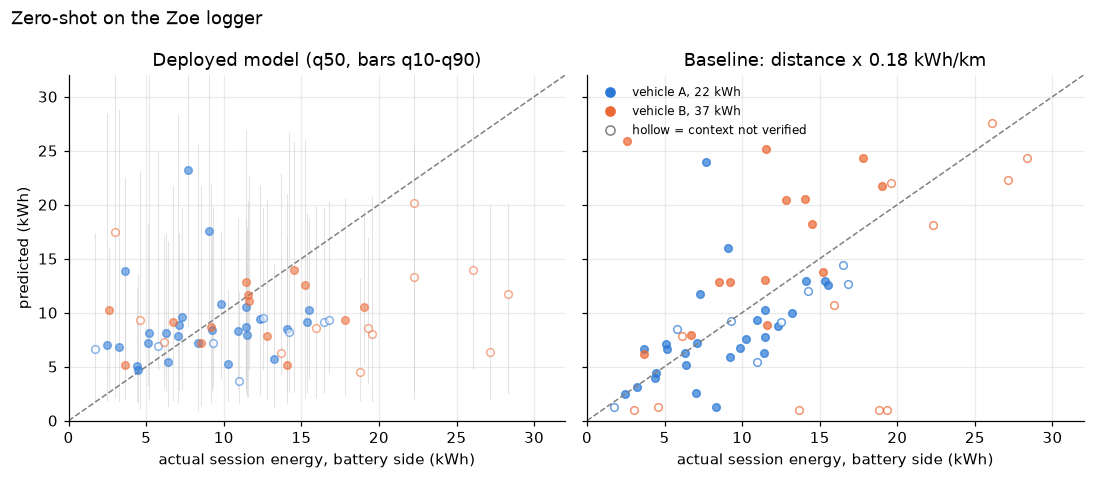

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharex=True, sharey=True)
colors = {"A": "#2a78d6", "B": "#eb6834"}
for ax, (title, col) in zip(axes, [("Deployed model (q50, bars q10-q90)", "q50"), ("Baseline: distance x 0.18 kWh/km", "baseline")]):
    for v, c in colors.items():
        d = ZT[ZT.household == v]
        for filled, dd in ((True, d[d.clean]), (False, d[~d.clean])):
            if col == "q50":
                ax.errorbar(dd.energy_kwh, dd.q50, yerr=[dd.q50 - dd.q10, dd.q90 - dd.q50], fmt="o", ms=5, alpha=0.55, color=c,
                            mfc=c if filled else "white", ecolor="#cfcfcf", lw=0.7)
            else:
                ax.plot(dd.energy_kwh, dd[col], "o", ms=5, alpha=0.7, color=c, mfc=c if filled else "white")
    lim = 32
    ax.plot([0, lim], [0, lim], "--", color="grey", lw=1)
    ax.set(title=title, xlabel="actual session energy, battery side (kWh)", xlim=(0, lim), ylim=(0, lim))
axes[0].set_ylabel("predicted (kWh)")
axes[1].plot([], [], "o", color=colors["A"], label="vehicle A, 22 kWh")
axes[1].plot([], [], "o", color=colors["B"], label="vehicle B, 37 kWh")
axes[1].plot([], [], "o", mfc="white", color="grey", label="hollow = context not verified")
axes[1].legend(loc="upper left", fontsize=8)
fig.suptitle("Zero-shot on the Zoe logger", x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 3.6 · Is the verdict an artefact of my extraction choices, or of the inputs the Zoe cannot provide?

Three sensitivity families: (i) the extraction parameters, (ii) the two inputs the logger cannot supply (tariff, PV) and
the incomparable `trips_today`, (iii) battery-side vs wall-side energy.

In [11]:
rows = []
for soc, gap, trip in [(2.0, 60, 5), (1.0, 60, 5), (4.0, 60, 5), (2.0, 30, 5), (2.0, 180, 5), (2.0, 60, 2), (2.0, 60, 15)]:
    T_ = zoe_table(MIN, CAP, soc, gap, trip)
    a, c = np.ones(len(T_), bool), T_.clean.to_numpy()
    y = T_.energy_kwh.to_numpy()
    rows.append({"min SoC rise %": soc, "merge gap min": gap, "trip gap min": trip,
                 "n all": int(a.sum()), "model MAE (all)": round(float(np.mean(np.abs(T_.q50 - y))), 2),
                 "baseline MAE (all)": round(float(np.mean(np.abs(T_.baseline - y))), 2),
                 "n clean": int(c.sum()), "model MAE (clean)": round(float(np.mean(np.abs(T_.q50[c] - y[c]))), 2),
                 "baseline MAE (clean)": round(float(np.mean(np.abs(T_.baseline[c] - y[c]))), 2)})
sweep = pd.DataFrame(rows)
sweep["model vs baseline, all %"] = (100 * (sweep["baseline MAE (all)"] - sweep["model MAE (all)"]) / sweep["baseline MAE (all)"]).round(0)
sweep["model vs baseline, clean %"] = (100 * (sweep["baseline MAE (clean)"] - sweep["model MAE (clean)"]) / sweep["baseline MAE (clean)"]).round(0)
display(sweep)
RESULTS["zoe_sweep_gain_all_pct"] = [float(sweep["model vs baseline, all %"].min()), float(sweep["model vs baseline, all %"].max())]
RESULTS["zoe_sweep_gain_clean_pct"] = [float(sweep["model vs baseline, clean %"].min()), float(sweep["model vs baseline, clean %"].max())]
print("positive = model better than the baseline")

# (ii) inputs the Zoe cannot provide
y = ZT.energy_kwh.to_numpy()
def mae_with(**over):
    X = ZT[FEATURES].copy()
    for k, v in over.items():
        X[k] = v
    return round(float(np.mean(np.abs(predict_sorted(MODELS, X.to_numpy(float))[1] - y))), 2)
sens = {"as run (tariff unknown, PV 0)": mae_with(), "tariff band 0 / 1 / 3": f"{mae_with(tariff_ordinal=0)} / {mae_with(tariff_ordinal=1)} / {mae_with(tariff_ordinal=3)}",
        "PV today = 3 kWh / 8 kWh": f"{mae_with(pv_today_kwh=3.0)} / {mae_with(pv_today_kwh=8.0)}",
        "trips_today = 0 / 8 (pilot median)": f"{mae_with(trips_today=0)} / {mae_with(trips_today=8)}"}
X_perm = ZT[FEATURES].copy()
X_perm["hour_of_day"], X_perm["is_weekend"] = rng.permutation(X_perm.hour_of_day.values), rng.permutation(X_perm.is_weekend.values)
sens["hour_of_day and is_weekend shuffled"] = round(float(np.mean(np.abs(predict_sorted(MODELS, X_perm.to_numpy(float))[1] - y))), 2)
display(pd.Series(sens, name="model MAE (kWh), all sessions").to_frame())
imp = pd.Series(MODELS["q50"].feature_importances_, index=FEATURES).sort_values(ascending=False).round(3)
print("q50 feature importances (Dingle-trained):", imp.to_dict())

# (iii) battery side vs wall side
rows = []
for eff in (1.0, 0.87):
    yy, c = y / eff, ZT.clean.to_numpy()
    rows.append({"battery-to-wall efficiency": eff, "model MAE all": round(float(np.mean(np.abs(ZT.q50 - yy))), 2),
                 "baseline MAE all": round(float(np.mean(np.abs(ZT.baseline - yy))), 2),
                 "model MAE clean": round(float(np.mean(np.abs(ZT.q50[c] - yy[c]))), 2), "baseline MAE clean": round(float(np.mean(np.abs(ZT.baseline[c] - yy[c]))), 2)})
display(pd.DataFrame(rows).set_index("battery-to-wall efficiency"))

worst = ZT.assign(error=ZT.q50 - ZT.energy_kwh)
worst = worst.loc[worst.error.abs().sort_values(ascending=False).index].head(6)
display(worst[["household", "start", "recent_trip_km", "hours_since_last_charge", "energy_kwh", "q10", "q50", "q90", "baseline", "clean"]].round(2))

pack = ZT.household.map(CAP)
long_gap = ZT.hours_since_last_charge > 400
print(f"predictions above the car's usable pack size: q50 {int((ZT.q50 > pack).sum())}, q90 {int((ZT.q90 > pack).sum())} of {len(ZT)} sessions")
print(f"sessions more than 400 h after the previous one: {int(long_gap.sum())} | model MAE {np.mean(np.abs(ZT.q50 - ZT.energy_kwh)[long_gap]):.1f} "
      f"vs baseline {np.mean(np.abs(ZT.baseline - ZT.energy_kwh)[long_gap]):.1f} kWh there; elsewhere {np.mean(np.abs(ZT.q50 - ZT.energy_kwh)[~long_gap]):.1f} "
      f"vs {np.mean(np.abs(ZT.baseline - ZT.energy_kwh)[~long_gap]):.1f} kWh")
RESULTS["zoe_long_gap"] = {"n": int(long_gap.sum()), "model_mae": round(float(np.mean(np.abs(ZT.q50 - ZT.energy_kwh)[long_gap])), 2),
                           "baseline_mae": round(float(np.mean(np.abs(ZT.baseline - ZT.energy_kwh)[long_gap])), 2),
                           "model_mae_rest": round(float(np.mean(np.abs(ZT.q50 - ZT.energy_kwh)[~long_gap])), 2),
                           "baseline_mae_rest": round(float(np.mean(np.abs(ZT.baseline - ZT.energy_kwh)[~long_gap])), 2)}

,min SoC rise %,merge gap min,trip gap min,n all,model MAE (all),baseline MAE (all),n clean,model MAE (clean),baseline MAE (clean),"model vs baseline, all %","model vs baseline, clean %"
0,2.0,60,5,62,5.19,4.42,41,3.67,3.98,-17.0,8.0
1,1.0,60,5,62,5.20,4.44,42,3.86,4.35,-17.0,11.0
2,4.0,60,5,62,5.19,4.42,41,3.67,3.98,-17.0,8.0
3,2.0,30,5,62,5.19,4.42,41,3.67,3.98,-17.0,8.0
4,2.0,180,5,61,5.09,4.43,41,3.67,3.98,-15.0,8.0
5,2.0,60,2,62,5.21,4.54,41,3.68,4.16,-15.0,12.0
6,2.0,60,15,62,5.18,4.31,41,3.65,3.81,-20.0,4.0


positive = model better than the baseline


,"model MAE (kWh), all sessions"
"as run (tariff unknown, PV 0)",5.19
tariff band 0 / 1 / 3,5.19 / 5.19 / 5.19
PV today = 3 kWh / 8 kWh,5.24 / 5.13
trips_today = 0 / 8 (pilot median),4.96 / 5.32
hour_of_day and is_weekend shuffled,5.62


q50 feature importances (Dingle-trained): {'hour_of_day': 0.333, 'recent_trip_km': 0.258, 'hours_since_last_charge': 0.146, 'trips_today': 0.133, 'pv_today_kwh': 0.121, 'is_weekend': 0.01, 'tariff_ordinal': 0.0}


,model MAE all,baseline MAE all,model MAE clean,baseline MAE clean
battery-to-wall efficiency,,,,
1.00,5.19,4.42,3.67,3.98
0.87,6.32,5.02,4.39,4.18


,household,start,recent_trip_km,hours_since_last_charge,energy_kwh,q10,q50,q90,baseline,clean
57,B,2021-03-10 13:24:00,99.23,458.05,27.14,2.03,6.39,19.93,22.33,False
59,B,2021-05-06 07:57:00,128.62,527.87,28.33,2.47,11.71,20.13,24.31,False
24,A,2020-02-16 19:16:00,102.33,57.88,7.68,8.66,23.18,46.06,23.94,True
44,B,2020-08-18 00:00:00,0.00,1.82,3.01,2.08,17.43,48.88,1.00,False
35,B,2020-05-14 13:55:00,0.80,18.00,18.80,1.77,4.53,13.17,1.00,False
49,B,2021-01-12 17:13:00,133.15,524.55,26.07,4.78,13.99,37.08,27.56,False


predictions above the car's usable pack size: q50 1, q90 11 of 62 sessions
sessions more than 400 h after the previous one: 8 | model MAE 10.1 vs baseline 4.8 kWh there; elsewhere 4.5 vs 4.4 kWh


**Reading Part A.** Look at the long-gap line above: the sessions that follow multi-week gaps are where the model and the baseline
part ways, in a region (hours since the last charge > 400) where the pilot's training data is very thin (its 90th percentile
is ~100 h). The model has **no battery-capacity input**, so nothing stops it predicting more energy than the car's pack holds
(counted above). On the other sessions the model and the baseline are level; the long-gap sessions are where they part. A constant
equal to the Zoe's *own* median session energy (the oracle column in §3.5) scores about as well as the model. With this few sessions the
confidence intervals include both "no better than the baseline" and a modest advantage: the data exclude only a large transfer gain.

### 3.7 · A small open sample for the model repository

The Hugging Face package (`Data/models/`) has to ship a small data set and a short script that runs the model. The pilot's training data
is restricted and cannot be redistributed, so the open Zoe sessions are used instead: the sessions of §3.3 in the model's exact feature
schema with their measured energy, **without timestamps**. It is out of domain for the model, so it shows how to load and run the model,
not how accurate it is. It derives from [Zenodo 7033914](https://zenodo.org/records/7033914) (Morea, Alessandrini & Spadaro, 2022,
CC-BY-4.0) and keeps that licence. It is written to `outputs/example_sessions.csv` and into `Data/models/` (the model package ships it:
the card's sample numbers are `example.py`'s output on that file).

In [12]:
PUBLISH_SAMPLE_TO_MODEL_DIR = True        # also write the sample into Data/models/ (the Hugging Face package)

sample = (ZT[["household"] + FEATURES + ["energy_kwh", "clean"]]
          .rename(columns={"household": "vehicle", "clean": "context_verified"}).reset_index(drop=True))
sample["session"] = sample.vehicle + "-" + sample.groupby("vehicle").cumcount().add(1).astype(str).str.zfill(2)
sample = sample[["session", "vehicle"] + FEATURES + ["energy_kwh", "context_verified"]]
# no rounding: at 6 decimals one prediction crossed a float32 split boundary and example.py printed 3.68 instead of 3.67
sample.to_csv(OUT_DIR / "example_sessions.csv", index=False)
if PUBLISH_SAMPLE_TO_MODEL_DIR:
    sample.to_csv(ROOT / "Data" / "models" / "example_sessions.csv", index=False)
display(sample.head(6))
print(f"{len(sample)} sessions ({int(sample.context_verified.sum())} with a verified context) -> outputs/example_sessions.csv"
      + (" and Data/models/example_sessions.csv" if PUBLISH_SAMPLE_TO_MODEL_DIR else ""))

,session,vehicle,recent_trip_km,trips_today,hours_since_last_charge,tariff_ordinal,pv_today_kwh,hour_of_day,is_weekend,energy_kwh,context_verified
0,A-01,A,7.142,1,18.000000,2.0,0.0,8.316667,0.0,1.719879,False
1,A-02,A,38.157,3,3.316667,2.0,0.0,12.233333,0.0,10.247984,True
2,A-03,A,71.680,1,18.100000,2.0,0.0,7.466667,0.0,15.363065,True
3,A-04,A,34.933,2,7.616667,2.0,0.0,16.683333,0.0,5.159637,True
4,A-05,A,42.833,1,13.450000,2.0,0.0,6.683333,0.0,11.495565,True
5,A-06,A,37.462,1,47.500000,2.0,0.0,7.433333,0.0,9.846976,True


62 sessions (41 with a verified context) -> outputs/example_sessions.csv and Data/models/example_sessions.csv


## 4 · Part B — the heads on 35,377 Norwegian residential sessions

**Source.** Sørensen *et al.*, *Electric vehicle charging dataset with 35,000 charging sessions from 12 residential
locations in Norway*, [Zenodo 13896176](https://zenodo.org/records/13896176), CC-BY-4.0 — shared charging in apartment buildings
(Asker, Bærum, Bergen, Bodø, Krokkleiva, Oslo, Trondheim), 2018–2021. `Dataset1_charging_reports.csv` is operator-measured
(`user_id`, `plugin_time`, `plugout_time`, `energy_session`); it is the only file used.

**What is re-fitted.** The harness, model families and hyper-parameters are those of `EV_Charging_Analysis.ipynb`
(expanding-window walk-forward, monthly test blocks, six months of initial history; logistic regression and LightGBM with the
notebook's settings). **Removed:** every driving feature (`km_*`, `km_since_charge`) and the reconstructed state of charge,
which needs distance. **Added:** per-user history that exists here — recent charge frequency, the energy of recent sessions,
and a `need_proxy` (days since the last charge × the 28-day energy pace). Users with fewer than 30 sessions are dropped
(206 of 267 kept). A 28-day warm-up per user avoids unstable histories.

The Norwegian sites show **no site-level outage** (the longest silent gap at any site is 6 days), so nothing is masked.

In [13]:
MIN_SESSIONS, WARMUP_DAYS, MIN_HISTORY_MONTHS = 30, 28, 6

raw = pd.read_csv(NORWAY_CSV, sep=";", decimal=",", parse_dates=["plugin_time", "plugout_time"])
raw = raw.sort_values(["user_id", "plugin_time"]).reset_index(drop=True)
raw["day"] = raw.plugin_time.dt.normalize()
site_gap = raw.groupby("location").day.apply(lambda s: int(np.diff(np.sort(s.unique())).astype("timedelta64[D]").astype(int).max()))
print(f"{len(raw):,} sessions · {raw.user_id.nunique()} users · {raw.location.nunique()} sites · {raw.plugin_time.min():%d %b %Y} -> "
      f"{raw.plugin_time.max():%d %b %Y} · longest silent gap at any site: {site_gap.max()} days")
print(f"energy per session: median {raw.energy_session.median():.1f} kWh, mean {raw.energy_session.mean():.1f}, p95 {raw.energy_session.quantile(.95):.1f} | "
      f"dwell: median {((raw.plugout_time - raw.plugin_time).dt.total_seconds() / 3600).median():.1f} h | "
      f"user-days with more than one session: {100 * (raw.groupby(['user_id', 'day']).size() > 1).mean():.0f}%")
site_last = raw.groupby("location").day.max()
count = raw.groupby("user_id").size()
raw = raw[raw.user_id.isin(count[count >= MIN_SESSIONS].index)].reset_index(drop=True)
print(f"kept {raw.user_id.nunique()} users with >= {MIN_SESSIONS} sessions ({len(raw):,} sessions)")


def build_panel(uid, d):
    # One row per user-day between the user's first and last session; every feature is lagged (known at the start of the day).
    idx = pd.date_range(d.day.min(), d.day.max(), freq="D")
    p = pd.DataFrame({"uid": uid, "site": d.location.iloc[0], "date": idx,
                      "kwh": d.groupby("day").energy_session.sum().reindex(idx, fill_value=0.0).values,
                      "n_sess": d.groupby("day").size().reindex(idx, fill_value=0).values})
    p["y"] = (p.n_sess > 0).astype(int)
    p["dow"], p["month"] = p.date.dt.dayofweek, p.date.dt.month
    p["is_we"] = (p.dow >= 5).astype(int)
    for w in (1, 3, 7, 14, 28):
        p[f"chg_{w}d"] = p.y.shift(1).rolling(w, min_periods=1).mean()
    for w in (7, 14, 28):
        p[f"kwh_{w}d"] = p.kwh.shift(1).rolling(w, min_periods=1).sum()
    p["user_rate"] = p.y.shift(1).expanding().mean()
    p["dow_rate"] = p.groupby("dow").y.transform(lambda s: s.shift(1).expanding().mean()).fillna(p.user_rate)
    since, counter = [], 999
    for yv in p.y.to_numpy():
        since.append(counter)
        counter = 0 if yv else counter + 1
    p["days_since_charge"] = since
    p["need_proxy"] = np.minimum(p.days_since_charge, 60) * p.kwh_28d / 28.0
    p["first_day"], p["last_day"] = idx[0], idx[-1]
    return p


PANEL = pd.concat([build_panel(u, d) for u, d in raw.groupby("user_id")], ignore_index=True)


def make_train(window="user"):
    # 'user': each user's days run from the first to the last session (the last day is dropped: it is a charge by construction).
    # 'site': days run to the end of the user's site data collection, so a long absence after the last session counts as no-charge days.
    if window == "user":
        t = PANEL[(PANEL.date >= PANEL.first_day + pd.Timedelta(days=WARMUP_DAYS)) & (PANEL.date < PANEL.last_day)].copy()
    else:
        parts = []
        for u, d in raw.groupby("user_id"):
            end = site_last[d.location.iloc[0]]
            p = build_panel(u, d)
            if end > p.date.max():
                pad = d.iloc[[-1]].assign(day=end, energy_session=0.0)             # a placeholder row that extends the day range ...
                p = build_panel(u, pd.concat([d, pad], ignore_index=True))
                p.loc[p.date == end, ["y", "n_sess"]] = [0, 0]                   # ... and is not a real session
            parts.append(p)
        p = pd.concat(parts, ignore_index=True)
        t = p[p.date >= p.first_day + pd.Timedelta(days=WARMUP_DAYS)].copy()
    t["ym"] = t.date.dt.to_period("M")
    return t


TRAIN = make_train("user")
print(f"panel {len(PANEL):,} user-days -> {len(TRAIN):,} usable · charge-day rate {100 * TRAIN.y.mean():.1f}% · {TRAIN.uid.nunique()} users")


def walk_forward(df, features, target, make_model, kind="clf", start=MIN_HISTORY_MONTHS):
    months, folds = sorted(df.ym.unique()), []
    for month in months[start:]:
        train, test = df[df.ym < month], df[df.ym == month]
        if len(test) < 15 or len(train) < 100 or (kind == "clf" and test[target].nunique() < 2):
            continue
        model = make_model()
        model.fit(train[features], train[target])
        t = test.copy()
        if kind == "clf":
            t["pred"], t["baseline"] = model.predict_proba(test[features])[:, 1], train[target].mean()
        else:
            t["pred"], t["baseline"] = model.predict(test[features]), train[target].median()
        folds.append(t)
    return pd.concat(folds, ignore_index=True)


def score_classifier(oof):
    thr = np.quantile(oof.pred, 1 - oof.y.mean())
    yhat = (oof.pred > thr).astype(int)
    b, b0 = brier_score_loss(oof.y, oof.pred), brier_score_loss(oof.y, oof.baseline)
    return {"n": len(oof), "pos_rate_%": round(100 * oof.y.mean(), 1), "roc_auc": round(roc_auc_score(oof.y, oof.pred), 3),
            "pr_auc": round(average_precision_score(oof.y, oof.pred), 3), "brier_skill": round(1 - b / b0, 3),
            "recall@base-rate": round(f1_score(oof.y, yhat), 3)}


def score_regressor(oof, target):
    mae, mae0 = mean_absolute_error(oof[target], oof.pred), mean_absolute_error(oof[target], oof.baseline)
    return {"n": len(oof), "mae": round(mae, 2), "rmse": round(float(np.sqrt(((oof[target] - oof.pred) ** 2).mean())), 2),
            "mae_train_median": round(mae0, 2), "mean_actual": round(oof[target].mean(), 2), "nmae_%": round(100 * mae / oof[target].mean(), 1)}


def within_user_auc(oof, col="pred"):
    # AUC computed inside each user (who the user is cannot help), weighted by the user's number of test days
    a = [(len(g), roc_auc_score(g.y, g[col])) for _, g in oof.groupby("uid") if g.y.nunique() == 2 and len(g) >= 20]
    w, v = np.array([x[0] for x in a]), np.array([x[1] for x in a])
    return round(float(np.average(v, weights=w)), 3), len(a)

35,377 sessions · 267 users · 12 sites · 06 Feb 2018 -> 05 Aug 2021 · longest silent gap at any site: 6 days

energy per session: median 9.0 kWh, mean 12.7, p95 36.3 | dwell: median 11.2 h | user-days with more than one session: 22%
kept 206 users with >= 30 sessions (34,247 sessions)


panel 66,114 user-days -> 60,140 usable · charge-day rate 39.4% · 206 users


### 4.1 · Head A — will the user charge today?

Day-level probability, scored two ways: **pooled** ROC-AUC (as in the analysis notebook) and **within-user** AUC. The latter matters
here: with 206 users who differ enormously in how often they charge, much of a pooled AUC is simply *who the user is*.

In [14]:
FEATURE_SETS = {
    "recency-3": ["days_since_charge", "user_rate", "dow"],
    "history-9": ["days_since_charge", "user_rate", "dow_rate", "chg_7d", "chg_28d", "kwh_28d", "need_proxy", "dow", "is_we"],
    "wide-15": ["days_since_charge", "user_rate", "dow_rate", "chg_1d", "chg_3d", "chg_7d", "chg_14d", "chg_28d", "kwh_7d", "kwh_14d",
                "kwh_28d", "need_proxy", "dow", "is_we", "month"],
}
FAMILIES = {
    "logreg": lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=2000)),
    "lgbm": lambda: lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=7, min_child_samples=40, reg_lambda=5.0,
                                       colsample_bytree=0.7, verbose=-1, random_state=0),
}
rows, store = [], {}
for fs, feats in FEATURE_SETS.items():
    for fam, factory in FAMILIES.items():
        oof = walk_forward(TRAIN, feats, "y", factory)
        r = score_classifier(oof)
        r.update({"features": fs, "model": fam})
        r["within-user AUC"], r["users scored"] = within_user_auc(oof)
        rows.append(r)
        store[(fs, fam)] = oof
sweep_a = pd.DataFrame(rows).set_index(["features", "model"]).sort_values("roc_auc", ascending=False)
display(sweep_a)
BEST_A = sweep_a.index[0]
OOF_A = store[BEST_A]

pers = OOF_A.dropna(subset=["chg_1d"])
recency = walk_forward(TRAIN, ["days_since_charge"], "y", FAMILIES["logreg"])
base_a = pd.DataFrame([
    {"score": "persistence (charged yesterday)", "pooled AUC": roc_auc_score(pers.y, pers.chg_1d), "within-user AUC": within_user_auc(pers, "chg_1d")[0]},
    {"score": "user's overall charge-day rate (who the user is)", "pooled AUC": roc_auc_score(OOF_A.y, OOF_A.user_rate), "within-user AUC": within_user_auc(OOF_A, "user_rate")[0]},
    {"score": "user x weekday rate", "pooled AUC": roc_auc_score(OOF_A.y, OOF_A.dow_rate), "within-user AUC": within_user_auc(OOF_A, "dow_rate")[0]},
    {"score": "days since last charge only (logistic)", "pooled AUC": roc_auc_score(recency.y, recency.pred), "within-user AUC": within_user_auc(recency)[0]},
    {"score": f"selected: {BEST_A[0]} / {BEST_A[1]}", "pooled AUC": roc_auc_score(OOF_A.y, OOF_A.pred), "within-user AUC": within_user_auc(OOF_A)[0]},
]).set_index("score").round(3)
display(base_a)

OOF_A = OOF_A.copy()
OOF_A["quintile"] = pd.qcut(OOF_A.pred, 5, labels=False, duplicates="drop")
calib = OOF_A.groupby("quintile").agg(forecast=("pred", "mean"), observed=("y", "mean"), n=("y", "size")).round(3)
display(calib)

# sensitivity: let every user's days run to the end of the site's data collection (adds trailing no-charge days)
TRAIN_SITE = make_train("site")
oof_site = walk_forward(TRAIN_SITE, FEATURE_SETS[BEST_A[0]], "y", FAMILIES[BEST_A[1]])
site_row = {**score_classifier(oof_site), "within-user AUC": within_user_auc(oof_site)[0]}
print("window sensitivity ('site' window, same model):", {k: site_row[k] for k in ("n", "pos_rate_%", "roc_auc", "within-user AUC", "brier_skill")})

RESULTS["head_a"] = {**score_classifier(OOF_A), "configuration": f"{BEST_A[0]} / {BEST_A[1]}", "within_user_auc": within_user_auc(OOF_A)[0],
                     "user_rate_pooled_auc": round(roc_auc_score(OOF_A.y, OOF_A.user_rate), 3),
                     "user_rate_within_auc": within_user_auc(OOF_A, "user_rate")[0],
                     "lowest_quintile_pct": round(100 * calib.observed.iloc[0]), "top_quintile_pct": round(100 * calib.observed.iloc[-1]),
                     "site_window_roc_auc": site_row["roc_auc"], "site_window_within_user_auc": site_row["within-user AUC"]}

n  pos_rate_%  roc_auc  pr_auc  brier_skill  recall@base-rate  within-user AUC  users scored
features  model                                                                                                   
history-9 lgbm    56475        39.4    0.779   0.710        0.238             0.646            0.643           201
wide-15   lgbm    56475        39.4    0.778   0.709        0.236             0.645            0.641           201
history-9 logreg  56475        39.4    0.766   0.700        0.221             0.637            0.613           201
wide-15   logreg  56475        39.4    0.766   0.699        0.221             0.638            0.614           201
recency-3 lgbm    56475        39.4    0.747   0.672        0.189             0.613            0.581           201
          logreg  56475        39.4    0.737   0.657        0.171             0.605            0.550           201

,pooled AUC,within-user AUC
score,,
persistence (charged yesterday),0.618,0.536
user's overall charge-day rate (who the user is),0.724,0.505
user x weekday rate,0.728,0.560
days since last charge only (logistic),0.662,0.534
selected: history-9 / lgbm,0.779,0.643


,forecast,observed,n
quintile,,,
0,0.134,0.124,11295
1,0.239,0.228,11295
2,0.331,0.334,11295
3,0.490,0.502,11295
4,0.775,0.783,11295


window sensitivity ('site' window, same model): {'n': 60336, 'pos_rate_%': 37.2, 'roc_auc': 0.795, 'within-user AUC': 0.66, 'brier_skill': 0.258}


### 4.2 · Session energy — and does the deployed *design* hold up?

Two views of the same question, "how much energy will this session deliver?":

1. the analysis notebook's **walk-forward LightGBM** on session-level features;
2. the deployed model's **design** — three scikit-learn quantile gradient-boosting regressors (q10 / q50 / q90, the exact
   hyper-parameters in `metrics.json`), trained on the earliest 80 % and scored on the latest 20 %, with calibration of the
   q10–q90 band. Two feature sets: the **three deployed features that exist here** (`hours_since_last_charge`, `hour_of_day`,
   `is_weekend`) and those three **plus per-user history**.

Yardsticks: the global median, and the **user's trailing median of their previous 5 sessions**.

In [15]:
S = raw.copy()
S["dwell_h"] = (S.plugout_time - S.plugin_time).dt.total_seconds() / 3600
S["hour_of_day"] = S.plugin_time.dt.hour + S.plugin_time.dt.minute / 60
S["dow"], S["month"] = S.plugin_time.dt.dayofweek, S.plugin_time.dt.month
S["is_weekend"] = (S.dow >= 5).astype(int)
g = S.groupby("user_id")
S["hours_since_last_charge"] = ((S.plugin_time - g.plugout_time.shift()).dt.total_seconds() / 3600).clip(lower=0)
S["n_prior"] = g.cumcount()
S["user_last_kwh"] = g.energy_session.shift()
S["user_med5_kwh"] = g.energy_session.transform(lambda s: s.shift().rolling(5, min_periods=3).median())
S["user_mean_kwh"] = g.energy_session.transform(lambda s: s.shift().expanding(min_periods=3).mean())
S["user_med5_dwell"] = g.dwell_h.transform(lambda s: s.shift().rolling(5, min_periods=3).median())
S["user_last_dwell"] = g.dwell_h.shift()


def prior_window(col, days, how):
    # count / sum of the user's sessions that STARTED in the `days` days strictly before this session
    out = np.empty(len(S))
    for _, d in S.groupby("user_id", sort=False):
        r = d.set_index("plugin_time")[col].rolling(f"{days}D", closed="left")
        out[S.index.get_indexer(d.index)] = (r.sum() if how == "sum" else r.count()).to_numpy()
    return np.nan_to_num(out)


S["sessions_7d"] = prior_window("energy_session", 7, "count")
S["kwh_7d"] = prior_window("energy_session", 7, "sum")
S["kwh_28d"] = prior_window("energy_session", 28, "sum")
rate = PANEL.set_index(["uid", "date"]).user_rate
S["user_rate"] = [rate.get((u, d), np.nan) for u, d in zip(S.user_id, S.day)]
S["ym"], S["uid"], S["site"] = S.plugin_time.dt.to_period("M"), S.user_id, S.location
SESS = S[(S.n_prior >= 3) & S.user_med5_kwh.notna() & S.hours_since_last_charge.notna() & S.user_rate.notna()].copy()
print(f"{len(SESS):,} of {len(S):,} sessions have >= 3 earlier sessions of the same user")

B_FEATURES = ["hour_of_day", "dow", "month", "hours_since_last_charge", "user_last_kwh", "user_med5_kwh", "user_mean_kwh",
              "sessions_7d", "kwh_7d", "kwh_28d", "user_rate", "user_med5_dwell"]
session_model = lambda: lgb.LGBMRegressor(n_estimators=400, learning_rate=0.04, num_leaves=15, min_child_samples=20, subsample=0.9,
                                          subsample_freq=1, colsample_bytree=0.8, reg_lambda=2.0, verbose=-1, random_state=0)
OOF_B = walk_forward(SESS, B_FEATURES, "energy_session", session_model, "reg")
head_b = score_regressor(OOF_B, "energy_session")
head_b["mae_user_trailing_median5"] = round(mean_absolute_error(OOF_B.energy_session, OOF_B.user_med5_kwh), 2)
print("walk-forward LightGBM:", head_b)

# ---- the deployed design: quantile GBR, chronological 80/20 over all users (as in EV_Session_Energy_Model.ipynb §4-6)
GBR = {"loss": "quantile", "init": "zero", "n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "min_samples_leaf": 25, "subsample": 0.85}
D = SESS.sort_values("plugin_time").reset_index(drop=True)
cut = int(len(D) * 0.8)
tr, te = D.iloc[:cut], D.iloc[cut:]
unseen = 100 * (~te.site.isin(set(tr.site))).mean()
unseen_users = 100 * (~te.uid.isin(set(tr.uid))).mean()
print(f"train {len(tr):,} ({tr.plugin_time.min():%d %b %Y} -> {tr.plugin_time.max():%d %b %Y}) | test {len(te):,} "
      f"({te.plugin_time.min():%d %b %Y} -> {te.plugin_time.max():%d %b %Y}) | test sessions at sites unseen in training: {unseen:.0f}%, "
      f"from users unseen in training: {unseen_users:.0f}%")


def quantile_fit(feats, seed=42):
    models = {q: GradientBoostingRegressor(alpha=a, random_state=seed, **GBR).fit(tr[feats], tr.energy_session) for q, a in QUANTILES.items()}
    return np.sort(np.vstack([models[q].predict(te[feats]) for q in QUANTILES]), axis=0)


def score_q(y, lo, mid, hi):
    e = mid - y
    return {"MAE": round(float(np.mean(np.abs(e))), 2), "RMSE": round(float(np.sqrt(np.mean(e ** 2))), 2), "bias": round(float(np.mean(e)), 2),
            "q10-q90 coverage %": round(100 * float(np.mean((lo <= y) & (y <= hi))), 1)}


y = te.energy_session.to_numpy()
const = lambda v: np.full(len(te), v)
SHARED = ["hours_since_last_charge", "hour_of_day", "is_weekend"]
HISTORY = SHARED + ["user_last_kwh", "user_med5_kwh", "user_mean_kwh", "sessions_7d", "kwh_7d", "kwh_28d"]
table = {
    "global train median": score_q(y, const(tr.energy_session.quantile(.1)), const(tr.energy_session.median()), const(tr.energy_session.quantile(.9))),
    "user trailing median of 5 (no band)": {"MAE": round(float(np.mean(np.abs(te.user_med5_kwh - y))), 2),
                                            "RMSE": round(float(np.sqrt(np.mean((te.user_med5_kwh - y) ** 2))), 2),
                                            "bias": round(float(np.mean(te.user_med5_kwh - y)), 2), "q10-q90 coverage %": np.nan},
    "quantile GBR, the 3 deployed features that exist here": score_q(y, *quantile_fit(SHARED)),
    "quantile GBR, those 3 + user history": score_q(y, *quantile_fit(HISTORY)),
}
display(pd.DataFrame(table).T)
RESULTS["session_energy"] = {"walk_forward": head_b, "chronological": table, "test_sites_unseen_pct": round(unseen), "test_users_unseen_pct": round(unseen_users)}

33,593 of 34,247 sessions have >= 3 earlier sessions of the same user


walk-forward LightGBM: {'n': 31481, 'mae': 4.84, 'rmse': 7.47, 'mae_train_median': 7.44, 'mean_actual': 12.43, 'nmae_%': 39.0, 'mae_user_trailing_median5': 5.42}
train 26,874 (09 Feb 2018 -> 23 Jan 2020) | test 6,719 (23 Jan 2020 -> 05 Aug 2021) | test sessions at sites unseen in training: 21%, from users unseen in training: 47%


,MAE,RMSE,bias,q10-q90 coverage %
global train median,8.41,12.84,-5.12,75.5
user trailing median of 5 (no band),5.52,8.93,-0.24,NaN
"quantile GBR, the 3 deployed features that exist here",7.52,11.64,-3.54,75.1
"quantile GBR, those 3 + user history",4.96,7.77,-0.96,81.2


### 4.3 · Energy volume over a horizon and over a portfolio

The analysis notebook's central claim: the error of *volume* forecasts falls as the horizon lengthens and the portfolio widens.
Here the portfolio is 40 users at a time, or whole sites. Two extra yardsticks, because the notebook compared only with the
training-set median: a **trailing 28-day average** (the user's energy over the previous 28 days, scaled to the horizon), which
needs no model at all.

horizon (days),1,3,7,14
per-user nMAE % (model),111.3,63.5,42.9,35.4
per-user nMAE % (trailing 28d),111.4,63.8,43.2,35.6
per-user nMAE % (train median),100.0,82.0,66.2,60.6
site nMAE % (model),31.7,18.6,14.2,12.9
site nMAE % (trailing 28d),31.9,19.0,14.5,12.9
fleet nMAE % (model),18.7,12.2,10.3,10.2
fleet nMAE % (trailing 28d),18.8,12.1,10.4,10.0
users in fleet (median),40.0,40.0,39.0,39.0


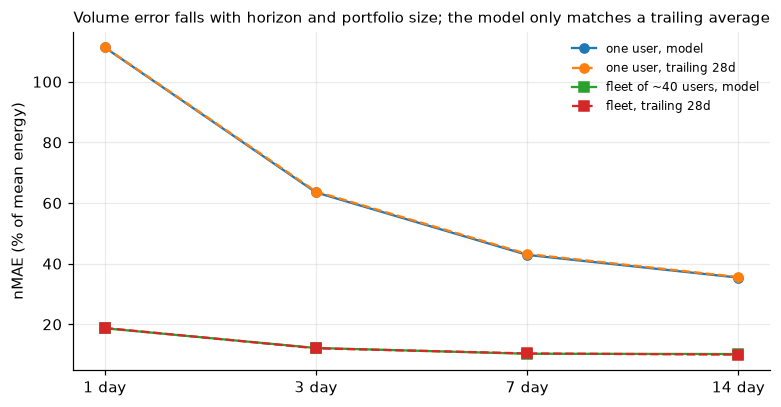

In [16]:
HORIZONS = [1, 3, 7, 14]
vol = TRAIN.copy()
for H in HORIZONS:
    vol[f"kwh_fwd{H}"] = vol.groupby("uid").kwh.transform(lambda s: s[::-1].rolling(H, min_periods=H).sum()[::-1])
VOL_FEATURES = ["days_since_charge", "user_rate", "chg_7d", "chg_28d", "kwh_7d", "kwh_14d", "kwh_28d", "need_proxy", "dow", "month"]
vol_model = lambda: lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=7, min_child_samples=40, reg_lambda=5.0,
                                      colsample_bytree=0.7, verbose=-1, random_state=0)
vrows = []
for H in HORIZONS:
    t = f"kwh_fwd{H}"
    oof = walk_forward(vol.dropna(subset=[t]), VOL_FEATURES, t, vol_model, "reg")
    oof["trailing"] = oof.kwh_28d / 28.0 * H
    r = score_regressor(oof, t)
    fleet = oof.groupby("date").agg(a=(t, "sum"), p=("pred", "sum"), tr=("trailing", "sum"), n=("uid", "nunique"))
    fleet = fleet[fleet.n >= 20]
    sites = oof.groupby(["site", "date"]).agg(a=(t, "sum"), p=("pred", "sum"), tr=("trailing", "sum"), n=("uid", "nunique"))
    sites = sites[sites.n >= 5]
    vrows.append({"horizon (days)": H, "per-user nMAE % (model)": r["nmae_%"],
                  "per-user nMAE % (trailing 28d)": round(100 * mean_absolute_error(oof[t], oof.trailing) / oof[t].mean(), 1),
                  "per-user nMAE % (train median)": round(100 * r["mae_train_median"] / r["mean_actual"], 1),
                  "site nMAE % (model)": round(100 * mean_absolute_error(sites.a, sites.p) / sites.a.mean(), 1),
                  "site nMAE % (trailing 28d)": round(100 * mean_absolute_error(sites.a, sites.tr) / sites.a.mean(), 1),
                  "fleet nMAE % (model)": round(100 * mean_absolute_error(fleet.a, fleet.p) / fleet.a.mean(), 1),
                  "fleet nMAE % (trailing 28d)": round(100 * mean_absolute_error(fleet.a, fleet.tr) / fleet.a.mean(), 1),
                  "users in fleet (median)": int(fleet.n.median())})
volume = pd.DataFrame(vrows).set_index("horizon (days)")
display(volume.T)
RESULTS["volume"] = volume.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(7.2, 3.8))
x = np.arange(len(HORIZONS))
for col, style, label in [("per-user nMAE % (model)", "-o", "one user, model"), ("per-user nMAE % (trailing 28d)", "--o", "one user, trailing 28d"),
                          ("fleet nMAE % (model)", "-s", "fleet of ~40 users, model"), ("fleet nMAE % (trailing 28d)", "--s", "fleet, trailing 28d")]:
    ax.plot(x, volume[col].values, style, label=label)
ax.set_xticks(x, [f"{h} day" for h in HORIZONS])
ax.set(ylabel="nMAE (% of mean energy)", title="Volume error falls with horizon and portfolio size; the model only matches a trailing average")
ax.title.set_fontsize(10)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 4.4 · Head C — the connection window

The plug-in window bounds every schedule an optimiser may propose, so it is predicted directly: dwell hours from the start
hour, weekday, month, time since the user's last session, the user's recent dwell and charging rate.

In [17]:
C_FEATURES = ["hour_of_day", "dow", "month", "hours_since_last_charge", "user_med5_dwell", "user_last_dwell", "user_rate"]
dwell_model = lambda: lgb.LGBMRegressor(n_estimators=250, learning_rate=0.05, num_leaves=10, min_child_samples=15, verbose=-1, random_state=0)
OOF_C = walk_forward(SESS.dropna(subset=C_FEATURES + ["dwell_h"]), C_FEATURES, "dwell_h", dwell_model, "reg")
head_c = score_regressor(OOF_C, "dwell_h")
head_c["mae_user_trailing_median5"] = round(mean_absolute_error(OOF_C.dwell_h, OOF_C.user_med5_dwell), 2)
head_c["median_dwell_h"] = round(float(S.dwell_h.median()), 2)
head_c["mae_over_median_dwell"] = round(head_c["mae"] / head_c["median_dwell_h"], 2)
print(head_c)
RESULTS["head_c"] = head_c

{'n': 31452, 'mae': 7.17, 'rmse': 12.09, 'mae_train_median': 8.03, 'mean_actual': 12.83, 'nmae_%': 55.9, 'mae_user_trailing_median5': 7.72, 'median_dwell_h': 11.25, 'mae_over_median_dwell': 0.64}


### 4.5 · User segmentation

The spec asks for segmentation quality (silhouette, purity). With four households the analysis notebook assigned segments by
rule; with 200 users a clustering is possible. Profile per user: charge-day rate, mean energy per session, median dwell, share of
evening starts (17–23 h), share of weekend starts. Standardised k-means; stability = adjusted Rand index between the full-data
clustering and clusterings fitted on 30 bootstrap resamples of the users.

In [18]:
prof = []
for u, d in raw.groupby("user_id"):
    dwell = (d.plugout_time - d.plugin_time).dt.total_seconds() / 3600
    prof.append({"uid": u, "charge_day_rate": d.day.nunique() / ((d.day.max() - d.day.min()).days + 1), "kwh_per_session": d.energy_session.mean(),
                 "dwell_median_h": dwell.median(), "evening_share": d.plugin_time.dt.hour.between(17, 23).mean(),
                 "weekend_share": (d.plugin_time.dt.dayofweek >= 5).mean()})
prof = pd.DataFrame(prof).dropna().set_index("uid")
Z = StandardScaler().fit_transform(prof)
rows, fits = [], {}
for k in range(2, 7):
    km = KMeans(k, n_init=20, random_state=0).fit(Z)
    fits[k] = km
    rng_b, aris = np.random.default_rng(1), []
    for _ in range(30):
        idx = rng_b.integers(0, len(Z), len(Z))
        aris.append(adjusted_rand_score(km.labels_, KMeans(k, n_init=5, random_state=0).fit(Z[idx]).predict(Z)))
    rows.append({"k": k, "silhouette": round(silhouette_score(Z, km.labels_), 3), "stability (ARI)": round(float(np.mean(aris)), 2),
                 "smallest cluster": int(np.bincount(km.labels_).min())})
seg = pd.DataFrame(rows).set_index("k")
display(seg)
best_k = int(seg.silhouette.idxmax())
prof["cluster"] = fits[best_k].labels_
display(prof.groupby("cluster").agg(users=("kwh_per_session", "size"), charge_day_rate=("charge_day_rate", "mean"), kwh_per_session=("kwh_per_session", "mean"),
                                    dwell_median_h=("dwell_median_h", "median"), evening_share=("evening_share", "mean"), weekend_share=("weekend_share", "mean")).round(2))
RESULTS["segmentation"] = {"best_k_by_silhouette": best_k, "silhouette_min": float(seg.silhouette.min()), "silhouette_max": float(seg.silhouette.max()),
                           "most_stable_k": int(seg["stability (ARI)"].idxmax()), "ari_k2": float(seg.loc[2, "stability (ARI)"]),
                           "ari_k3_to_6": [float(seg.loc[3:6, "stability (ARI)"].min()), float(seg.loc[3:6, "stability (ARI)"].max())], "users": int(len(prof))}

,silhouette,stability (ARI),smallest cluster
k,,,
2,0.212,0.79,101
3,0.208,0.62,50
4,0.216,0.56,28
5,0.222,0.57,30
6,0.211,0.53,17


,users,charge_day_rate,kwh_per_session,dwell_median_h,evening_share,weekend_share
cluster,,,,,,
0,57,0.67,8.74,9.13,0.54,0.26
1,34,0.47,10.84,14.88,0.35,0.18
2,30,0.32,31.19,12.07,0.57,0.29
3,55,0.32,13.71,14.32,0.58,0.32
4,30,0.24,16.52,4.70,0.28,0.24


## 5 · Part C — are the original yardsticks strong enough?

Both checks use only data and files the repository already has, so they run only where those exist.

The analysis notebook (`EV_Charging_Analysis.ipynb`) now carries the same strong baselines for its heads (§9–§11), and the model
card reports the no-model reference; this section keeps the cross-check for the deployed model and the volume head in one place.

**Session-energy model on the pilot hold-out.** The published baseline (distance × 0.18 kWh/km, +5 % per extra trip) is a
rule a service could use without training, but it is not a strong yardstick: it can be *worse than guessing a constant*. The
table puts the model next to naive predictors that need no driving data.

**Volume head.** `outputs/volume_by_horizon.csv` (written by `EV_Charging_Analysis.ipynb`) reports the model's error and its
"skill" against the training-set median. The cell below recomputes a trailing-28-day baseline on exactly the same walk-forward
rows (the row counts are compared) from `outputs/panel_daily.csv`.

In [19]:
if DINGLE is None:
    print("Dingle data not found - skipped.")
else:
    D = DINGLE.copy()
    cut = int(len(D) * 0.8)
    D["trailing5"] = D.groupby("household").energy_kwh.transform(lambda s: s.shift().rolling(5, min_periods=1).median())
    D["previous"] = D.groupby("household").energy_kwh.shift()
    held = D.iloc[cut:]
    med = D.iloc[:cut].energy_kwh.median()
    y = held.energy_kwh.to_numpy()
    cands = {"deployed model (q50)": predict_sorted(MODELS, held[FEATURES].to_numpy(float))[1],
             "published baseline (distance x 0.18, +5 %/trip)": baseline(held)[1],
             "distance x 0.18 only, no trip factor": np.clip(held.recent_trip_km.to_numpy() * 0.18, 1, 80),
             "constant: training median": np.full(len(held), med),
             "household's trailing median of 5 sessions": held.trailing5.fillna(med).to_numpy(),
             "household's previous session": held.previous.fillna(med).to_numpy()}
    t_ = pd.DataFrame({k: {"MAE": round(float(np.mean(np.abs(v - y))), 2), "RMSE": round(float(np.sqrt(np.mean((v - y) ** 2))), 2)} for k, v in cands.items()}).T
    published_mae = t_.loc["published baseline (distance x 0.18, +5 %/trip)", "MAE"]
    naive_keys = [k for k in t_.index if k != "deployed model (q50)" and not k.startswith("published")]
    best_naive = t_.loc[naive_keys, "MAE"].min()
    t_["MAE vs published baseline %"] = (100 * (t_.MAE - published_mae) / published_mae).round(0)
    t_["MAE vs best naive %"] = (100 * (t_.MAE - best_naive) / best_naive).round(0)
    display(t_)
    gaps = []
    rng_c = np.random.default_rng(0)
    naive = np.full(len(held), med)
    for _ in range(4000):
        s = rng_c.integers(0, len(y), len(y))
        gaps.append(np.mean(np.abs(naive[s] - y[s])) - np.mean(np.abs(cands["deployed model (q50)"][s] - y[s])))
    print(f"constant median minus model MAE, 95% CI {np.round(np.percentile(gaps, [2.5, 97.5]), 2)} kWh | P(model better) = {np.mean(np.array(gaps) > 0):.2f}")
    RESULTS["pilot_baselines"] = t_.to_dict(orient="index")

    pv, pp = OUT_DIR / "panel_daily.csv", OUT_DIR / "volume_by_horizon.csv"
    if pv.exists() and pp.exists():
        P = pd.read_csv(pv, parse_dates=["date"])
        pub = pd.read_csv(pp).set_index("horizon_days")
        T = P[~P.outage].copy().sort_values("date")
        T = T[T.date >= T.date.min() + pd.Timedelta(days=28)]
        T["ym"] = T.date.dt.to_period("M")
        out = []
        for H in (1, 3, 7, 14):
            T[f"f{H}"] = T.groupby("id").kwh.transform(lambda s: s[::-1].rolling(H, min_periods=H).sum()[::-1])
            dd = T.dropna(subset=[f"f{H}"])
            folds = []
            for mth in sorted(dd.ym.unique())[MIN_HISTORY_MONTHS:]:                 # the same rows as the analysis notebook's walk-forward
                if len(dd[dd.ym == mth]) >= 15 and len(dd[dd.ym < mth]) >= 100:
                    folds.append(dd[dd.ym == mth])
            o = pd.concat(folds)
            trail = o.kwh_28d / 28.0 * H
            fleet = o.assign(trail=trail).groupby("date").agg(a=(f"f{H}", "sum"), t=("trail", "sum"))
            out.append({"horizon (days)": H, "rows match published": int(len(o)) == int(pub.loc[H, "n"]),
                        "per-household MAE, published model": pub.loc[H, "mae"], "per-household MAE, trailing 28d": round(float(np.mean(np.abs(o[f"f{H}"] - trail))), 2),
                        "fleet MAE, published model": pub.loc[H, "fleet_mae"], "fleet MAE, trailing 28d": round(float(np.mean(np.abs(fleet.a - fleet.t))), 2)})
        vtab = pd.DataFrame(out).set_index("horizon (days)")
        display(vtab)
        RESULTS["pilot_volume"] = vtab.to_dict(orient="index")
    else:
        print("outputs/panel_daily.csv or outputs/volume_by_horizon.csv missing - run EV_Charging_Analysis.ipynb first; volume check skipped.")

,MAE,RMSE,MAE vs published baseline %,MAE vs best naive %
deployed model (q50),10.46,14.20,-44.0,-30.0
"published baseline (distance x 0.18, +5 %/trip)",18.72,25.88,0.0,26.0
"distance x 0.18 only, no trip factor",15.60,23.87,-17.0,5.0
constant: training median,14.85,18.45,-21.0,0.0
household's trailing median of 5 sessions,15.23,19.61,-19.0,3.0
household's previous session,17.60,22.16,-6.0,19.0


constant median minus model MAE, 95% CI [2.77 5.99] kWh | P(model better) = 1.00


,rows match published,"per-household MAE, published model","per-household MAE, trailing 28d","fleet MAE, published model","fleet MAE, trailing 28d"
horizon (days),,,,,
1,True,15.95,16.11,31.24,30.83
3,True,27.07,25.33,54.76,50.27
7,True,45.76,36.87,96.67,70.78
14,True,72.01,58.25,153.27,114.13


## 6 · Summary and limitations

In [20]:
def pct(a, b):
    return f"{100 * (a - b) / a:+.0f} %"

za, zc = RESULTS["zoe_all"], RESULTS["zoe_clean"]
ha = RESULTS["head_a"]
se = RESULTS["session_energy"]
lines = [
    "| Test | Result |", "|---|---|",
    f"| Pipeline parity with the published hold-out | {RESULTS['parity']} |",
    f"| **A** Zoe, all {int(za['n'])} sessions | model MAE {za['model MAE']} vs baseline {za['baseline MAE']} kWh; gap CI {za['gap_ci']} kWh; P(model better) {za['p_model_better']} |",
    f"| **A** Zoe, {int(zc['n'])} clean-context sessions | model MAE {zc['model MAE']} vs baseline {zc['baseline MAE']} kWh; gap CI {zc['gap_ci']} kWh; P(model better) {zc['p_model_better']} |",
    f"| **A** over {len(sweep)} extraction settings | model vs baseline {RESULTS['zoe_sweep_gain_all_pct'][0]:+.0f} % to {RESULTS['zoe_sweep_gain_all_pct'][1]:+.0f} % (all), {RESULTS['zoe_sweep_gain_clean_pct'][0]:+.0f} % to {RESULTS['zoe_sweep_gain_clean_pct'][1]:+.0f} % (clean) |",
    f"| **B** Head A will-charge ({ha['configuration']}) | pooled ROC-AUC {ha['roc_auc']}, **within-user {ha['within_user_auc']}** (user rate alone: pooled {ha['user_rate_pooled_auc']}, within {ha['user_rate_within_auc']}); lowest quintile charges on {ha['lowest_quintile_pct']} % of days, top on {ha['top_quintile_pct']} % |",
    f"| **B** session energy, quantile GBR with user history | MAE {se['chronological']['quantile GBR, those 3 + user history']['MAE']} kWh vs {se['chronological']['user trailing median of 5 (no band)']['MAE']} (user trailing median); q10-q90 coverage {se['chronological']['quantile GBR, those 3 + user history']['q10-q90 coverage %']} % |",
    f"| **B** session energy, the 3 deployed features only | MAE {se['chronological']['quantile GBR, the 3 deployed features that exist here']['MAE']} kWh; coverage {se['chronological']['quantile GBR, the 3 deployed features that exist here']['q10-q90 coverage %']} % |",
    f"| **B** volume, 7 days: user / fleet nMAE | model {RESULTS['volume'][7]['per-user nMAE % (model)']} % / {RESULTS['volume'][7]['fleet nMAE % (model)']} % vs trailing-28d {RESULTS['volume'][7]['per-user nMAE % (trailing 28d)']} % / {RESULTS['volume'][7]['fleet nMAE % (trailing 28d)']} % |",
    f"| **B** Head C dwell | MAE {RESULTS['head_c']['mae']} h vs median dwell {RESULTS['head_c']['median_dwell_h']} h (user trailing median {RESULTS['head_c']['mae_user_trailing_median5']} h) |",
    f"| **B** segmentation ({RESULTS['segmentation']['users']} users) | silhouette {RESULTS['segmentation']['silhouette_min']:.2f}-{RESULTS['segmentation']['silhouette_max']:.2f} for every k = 2-6 (no clear structure); stability ARI {RESULTS['segmentation']['ari_k2']:.2f} at k = 2, {RESULTS['segmentation']['ari_k3_to_6'][0]:.2f}-{RESULTS['segmentation']['ari_k3_to_6'][1]:.2f} for k >= 3 |",
]
if "pilot_baselines" in RESULTS:
    pb = RESULTS["pilot_baselines"]
    lines.append(f"| **C** pilot hold-out, session-energy model | MAE {pb['deployed model (q50)']['MAE']} kWh: {pb['deployed model (q50)']['MAE vs published baseline %']:+.0f} % vs the published baseline "
                 f"({pb['published baseline (distance x 0.18, +5 %/trip)']['MAE']}), but {pb['deployed model (q50)']['MAE vs best naive %']:+.0f} % vs the best naive predictor ({pb['constant: training median']['MAE']}, a constant training median) |")
if "pilot_volume" in RESULTS:
    pv_ = RESULTS["pilot_volume"]
    lines.append("| **C** pilot volume head, trailing-28d vs published model (MAE kWh) | per household " + ", ".join(f"{h} d: {pv_[h]['per-household MAE, trailing 28d']} vs {pv_[h]['per-household MAE, published model']}" for h in (1, 3, 7, 14))
                 + "; fleet " + ", ".join(f"{h} d: {pv_[h]['fleet MAE, trailing 28d']} vs {pv_[h]['fleet MAE, published model']}" for h in (1, 3, 7, 14)) + " |")
display(Markdown("\n".join(lines)))
(OUT_DIR / "external_validation.json").write_text(json.dumps(RESULTS, indent=2, default=str), encoding="utf-8")
print("wrote", (OUT_DIR / "external_validation.json").relative_to(ROOT).as_posix())

| Test | Result |
|---|---|
| Pipeline parity with the published hold-out | PASS |
| **A** Zoe, all 62 sessions | model MAE 5.191 vs baseline 4.421 kWh; gap CI (-2.1, 0.6) kWh; P(model better) 0.13 |
| **A** Zoe, 41 clean-context sessions | model MAE 3.674 vs baseline 3.983 kWh; gap CI (-0.94, 1.7) kWh; P(model better) 0.67 |
| **A** over 7 extraction settings | model vs baseline -20 % to -15 % (all), +4 % to +12 % (clean) |
| **B** Head A will-charge (history-9 / lgbm) | pooled ROC-AUC 0.779, **within-user 0.643** (user rate alone: pooled 0.724, within 0.505); lowest quintile charges on 12 % of days, top on 78 % |
| **B** session energy, quantile GBR with user history | MAE 4.96 kWh vs 5.52 (user trailing median); q10-q90 coverage 81.2 % |
| **B** session energy, the 3 deployed features only | MAE 7.52 kWh; coverage 75.1 % |
| **B** volume, 7 days: user / fleet nMAE | model 42.9 % / 10.3 % vs trailing-28d 43.2 % / 10.4 % |
| **B** Head C dwell | MAE 7.17 h vs median dwell 11.25 h (user trailing median 7.72 h) |
| **B** segmentation (206 users) | silhouette 0.21-0.22 for every k = 2-6 (no clear structure); stability ARI 0.79 at k = 2, 0.53-0.62 for k >= 3 |
| **C** pilot hold-out, session-energy model | MAE 10.46 kWh: -44 % vs the published baseline (18.72), but -30 % vs the best naive predictor (14.85, a constant training median) |
| **C** pilot volume head, trailing-28d vs published model (MAE kWh) | per household 1 d: 16.11 vs 15.95, 3 d: 25.33 vs 27.07, 7 d: 36.87 vs 45.76, 14 d: 58.25 vs 72.01; fleet 1 d: 30.83 vs 31.24, 3 d: 50.27 vs 54.76, 7 d: 70.78 vs 96.67, 14 d: 114.13 vs 153.27 |

wrote outputs/external_validation.json


### Limitations — read before quoting any number

* **Part A is a smoke test.** About 60 sessions from two cars with 22 and 37 kWh packs, mostly short morning top-ups (over half on
  20–21 kW AC chargers), logged across the 2020–21 COVID-19 restrictions by researchers at Area Science Park (Trieste), against a model
  trained on one pilot's overnight home charging. Energy is battery-side
  (SoC × pack size), the pilot's target is wall-side. Tariff and PV are unknown, and `trips_today` is not comparable.
  The confidence intervals are wide; the result can rule out a large transfer advantage but not a small one.
* **The extraction is mine, not the dataset's.** Sessions and journeys are reconstructed from raw signals with stated
  thresholds; §3.6 shows the conclusion is stable across them, and the completeness filter is a heuristic.
* **The saved model needs scikit-learn 1.5.2** (see the environment note at the top); the pin is in `requirements.txt`.
* **Part B does not test the saved model.** The Norwegian data has no driving data. It tests the heads' *approach* with a reduced
  feature set, in shared apartment-building charging that differs from the pilot's four households with their own wallbox and PV.
* **Pooled vs within-user scores.** Pooled AUC over many users is dominated by between-user differences; compare within-user AUC.
* **Each user's day range** runs from the first to the last session (a charge by construction); §4.1 repeats the head with
  days running to the end of the site's data collection.
* **No data leaves the machine except the two Zenodo downloads;** both are open (CC-BY-4.0). Cite
  Morea *et al.* (Zenodo 7033914) and Sørensen *et al.* (Zenodo 13896176, doi:10.1016/j.dib.2024.110883) when using these results.